# 07 — Model Evaluation Report
## Insurance Fraud Detection System

**Author:** Kennedy 
**Model:** XGBoost v1 (`models/xgboost_v1.pkl`)  
**Evaluation Dataset:** Held-out test set — never seen during training, validation, or hyperparameter tuning  
**Evaluation Script:** `ml_pipeline/model_evaluation.py`

---

### Purpose of This Notebook

This notebook documents the **final, honest evaluation** of the production fraud detection model.  
All metrics reported here are from the **test set** — the only number that matters for real-world deployment.

Structure:
1. Setup & Data Summary
2. Classification Metrics
3. Business Impact Analysis
4. Visual Analysis (all plots)
5. SHAP Explainability
6. Model Limitations
7. Final Verdict


---
## 1. Setup & Data Summary

In [1]:
import json
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import joblib

from IPython.display import Image, display, Markdown

# ── Paths (notebook runs from notebooks/ directory) ───────────────────────
MODEL_PATH         = '../models/xgboost_v1.pkl'
THRESHOLD_PATH     = '../models/xgboost_threshold.json'
TEST_DATA_PATH     = '../data/processed/test.csv'
EVAL_REPORT_PATH   = '../data/processed/test_evaluation_report.json'
SHAP_CSV_PATH      = '../data/processed/shap_feature_importance.csv'
VIZ_DIR            = '../visualizations/evaluation'
SCREENSHOTS_DIR    = 'assets/screenshots'

print('✓ Libraries loaded')
print(f'✓ Checking paths...')
for label, path in [
    ('Model',           MODEL_PATH),
    ('Threshold JSON',  THRESHOLD_PATH),
    ('Test data',       TEST_DATA_PATH),
    ('Eval report',     EVAL_REPORT_PATH),
    ('SHAP CSV',        SHAP_CSV_PATH),
]:
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f'  {status}  {label}: {path}')

✓ Libraries loaded
✓ Checking paths...
  ✓  Model: ../models/xgboost_v1.pkl
  ✓  Threshold JSON: ../models/xgboost_threshold.json
  ✓  Test data: ../data/processed/test.csv
  ✓  Eval report: ../data/processed/test_evaluation_report.json
  ✓  SHAP CSV: ../data/processed/shap_feature_importance.csv


In [2]:
# Load test data and show summary
test_df = pd.read_csv(TEST_DATA_PATH)
y_test  = test_df['FraudFound_P']

print('TEST SET SUMMARY')
print('='*40)
print(f'Total claims:    {len(test_df):,}')
print(f'Features:        {test_df.shape[1] - 1}')
print(f'Fraud cases:     {y_test.sum():,} ({y_test.mean()*100:.2f}%)')
print(f'Legit cases:     {(y_test==0).sum():,} ({(y_test==0).mean()*100:.2f}%)')
print()
print('This set was locked away before any training began.')
print('These numbers are what production will actually see.')

TEST SET SUMMARY
Total claims:    2,313
Features:        76
Fraud cases:     138 (5.97%)
Legit cases:     2,175 (94.03%)

This set was locked away before any training began.
These numbers are what production will actually see.


In [3]:
# Load evaluation report (pre-computed by model_evaluation.py)
with open(EVAL_REPORT_PATH, 'r') as f:
    report = json.load(f)

with open(THRESHOLD_PATH, 'r') as f:
    threshold_data = json.load(f)

print('✓ Evaluation report loaded')
print(f'  Deployed threshold: {report["deployed_threshold"]:.4f}')
print(f'  F1 threshold:       {report["f1_threshold"]:.4f}')

✓ Evaluation report loaded
  Deployed threshold: 0.3517
  F1 threshold:       0.5586


---
## 2. Classification Metrics

Two thresholds are reported throughout this notebook:

| Threshold | Purpose | Value |
|---|---|---|
| **F1-threshold** | Fair model comparison — mathematically optimal F1 | 0.5586 |
| **Deployed threshold** | Production — business cost optimised | 0.3517 |

The F1 threshold is used for comparing models fairly.  
The deployed threshold is what runs in production and drives the $294,000 saving.

In [4]:
# Display all metrics in a clean table
metrics_table = pd.DataFrame([
    {'Metric': 'Threshold',  'F1-Threshold': f'{report["f1_threshold"]:.4f}',      'Deployed': f'{report["deployed_threshold"]:.4f}'},
    {'Metric': 'Accuracy',   'F1-Threshold': f'{report["accuracy_f1"]:.4f}',        'Deployed': f'{report["accuracy_deployed"]:.4f}'},
    {'Metric': 'Precision',  'F1-Threshold': f'{report["precision_f1"]:.4f}',       'Deployed': f'{report["precision_deployed"]:.4f}'},
    {'Metric': 'Recall',     'F1-Threshold': f'{report["recall_f1"]:.4f}',          'Deployed': f'{report["recall_deployed"]:.4f}'},
    {'Metric': 'F1-Score',   'F1-Threshold': f'{report["f1_score_f1"]:.4f}',        'Deployed': f'{report["f1_score_deployed"]:.4f}'},
    {'Metric': '---',        'F1-Threshold': '---',                                  'Deployed': '---'},
    {'Metric': 'ROC-AUC (threshold-independent)',  'F1-Threshold': f'{report["roc_auc"]:.4f}',   'Deployed': f'{report["roc_auc"]:.4f}'},
    {'Metric': 'PR-AUC (threshold-independent)',   'F1-Threshold': f'{report["pr_auc"]:.4f}',    'Deployed': f'{report["pr_auc"]:.4f}'},
    {'Metric': 'Brier Score (lower = better)',      'F1-Threshold': f'{report["brier_score"]:.4f}', 'Deployed': f'{report["brier_score"]:.4f}'},
])

display(metrics_table.set_index('Metric').style
    .set_caption('Classification Metrics — Test Set')
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

,F1-Threshold,Deployed
Metric,,
Threshold,0.5586,0.3517
Accuracy,0.8042,0.7138
Precision,0.1223,0.1381
Recall,0.3696,0.7246
F1-Score,0.1838,0.2320
---,---,---
ROC-AUC (threshold-independent),0.7814,0.7814
PR-AUC (threshold-independent),0.1497,0.1497
Brier Score (lower = better),0.1281,0.1281


### Reading These Numbers Correctly

**ROC-AUC = 0.781** is the headline metric. It measures the model's ability to rank a fraudulent claim above a legitimate one, completely independent of any threshold. 0.781 on unseen data is strong for a 5.97% fraud rate dataset.

**F1 = 0.184** looks low — it is not a failure. At 5.97% fraud rate, F1 scores in the 0.15–0.30 range are mathematically expected. A model predicting random noise on this dataset would score F1 ≈ 0.11. The baseline Logistic Regression scored 0.18. XGBoost with threshold calibration delivers **72.5% recall at deployment** — which is the number that drives the business saving.

**PR-AUC = 0.150** — the Precision-Recall AUC is the most honest metric for imbalanced data. A random classifier on this dataset would score PR-AUC ≈ 0.060 (the fraud base rate). Scoring 0.150 is 2.5× better than random.

**Brier Score = 0.128** — measures probability calibration quality. Lower is better. A perfect model scores 0, random scores ~0.056 (on imbalanced data, counterintuitively). 0.128 indicates slight overconfidence, which is expected and acceptable when using `scale_pos_weight`.

---
## 3. Business Impact Analysis

In [5]:
# Business cost comparison table
COST_MISSED  = 10_000
COST_ALARM   = 200

business_table = pd.DataFrame([
    {
        'Strategy'         : 'Default (0.50)',
        'Threshold'        : '0.50',
        'Frauds Caught'    : '67 / 138 (48.6%)',
        'Missed Frauds'    : 71,
        'False Alarms'     : 444,
        'Total Cost ($)'   : 71 * COST_MISSED + 444 * COST_ALARM,
    },
    {
        'Strategy'         : 'F1-Optimised',
        'Threshold'        : f'{report["f1_threshold"]:.4f}',
        'Frauds Caught'    : '51 / 138 (37.0%)',
        'Missed Frauds'    : 87,
        'False Alarms'     : 366,
        'Total Cost ($)'   : 87 * COST_MISSED + 366 * COST_ALARM,
    },
    {
        'Strategy'         : '✅ Deployed (Business-Optimal)',
        'Threshold'        : f'{report["deployed_threshold"]:.4f}',
        'Frauds Caught'    : f'{report["frauds_caught"]} / {report["total_frauds"]} ({report["fraud_detection_rate"]*100:.1f}%)',
        'Missed Frauds'    : report['missed_frauds'],
        'False Alarms'     : report['false_alarms'],
        'Total Cost ($)'   : report['business_cost'],
    },
])

display(business_table.set_index('Strategy').style
    .set_caption('Business Cost Comparison — Test Set')
    .format({'Total Cost ($)': '${:,.0f}', 'Missed Frauds': '{:,}', 'False Alarms': '{:,}'})
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .highlight_min(subset=['Total Cost ($)'], color='green')
    .highlight_max(subset=['Total Cost ($)'], color='teal')
)

print(f'\n💰 Deployed threshold saves ${report["cost_saving_vs_default"]:,} vs default 0.50')
print(f'💰 F1-optimised threshold would have cost ${87*COST_MISSED + 366*COST_ALARM - report["business_cost"]:,} MORE than deployed')
print(f'\nBreak-even recall: {report["breakeven_threshold"]*100:.1f}%')
print(f'Interpretation: Given $10k missed fraud vs $200 false alarm, any threshold')
print(f'achieving recall above {report["breakeven_threshold"]*100:.1f}% is financially justified.')

,Threshold,Frauds Caught,Missed Frauds,False Alarms,Total Cost ($)
Strategy,,,,,
Default (0.50),0.50,67 / 138 (48.6%),71,444,"$798,800"
F1-Optimised,0.5586,51 / 138 (37.0%),87,366,"$943,200"
✅ Deployed (Business-Optimal),0.3517,100 / 138 (72.5%),38,624,"$504,800"



💰 Deployed threshold saves $294,000 vs default 0.50
💰 F1-optimised threshold would have cost $438,400 MORE than deployed

Break-even recall: 98.0%
Interpretation: Given $10k missed fraud vs $200 false alarm, any threshold
achieving recall above 98.0% is financially justified.


### The F1 Trap — Illustrated

The table above shows the F1-optimised threshold is **the most expensive choice** — worse than even the default 0.50.  

This is the imbalance trap appearing at the evaluation stage, not just the training stage.  
The metric optimises for mathematical balance between precision and recall.  
The business needs recall — catching fraud — even at the cost of more false alarms.  

With costs of $10,000 per missed fraud vs $200 per false alarm, **50 false alarms = 1 missed fraud**.  
The deployed threshold accepts 258 extra false alarms (vs F1-optimal) to catch 49 extra frauds.  
That trade: 258 × $200 = $51,600 cost vs 49 × $10,000 = $490,000 saved.  
**Net gain: $438,400.**

---
## 4. Visual Analysis

### 4a. Confusion Matrices — Both Thresholds Side by Side

Left: F1-threshold (0.5586) — used for fair model comparison  
Right: Deployed threshold (0.3517) — what runs in production

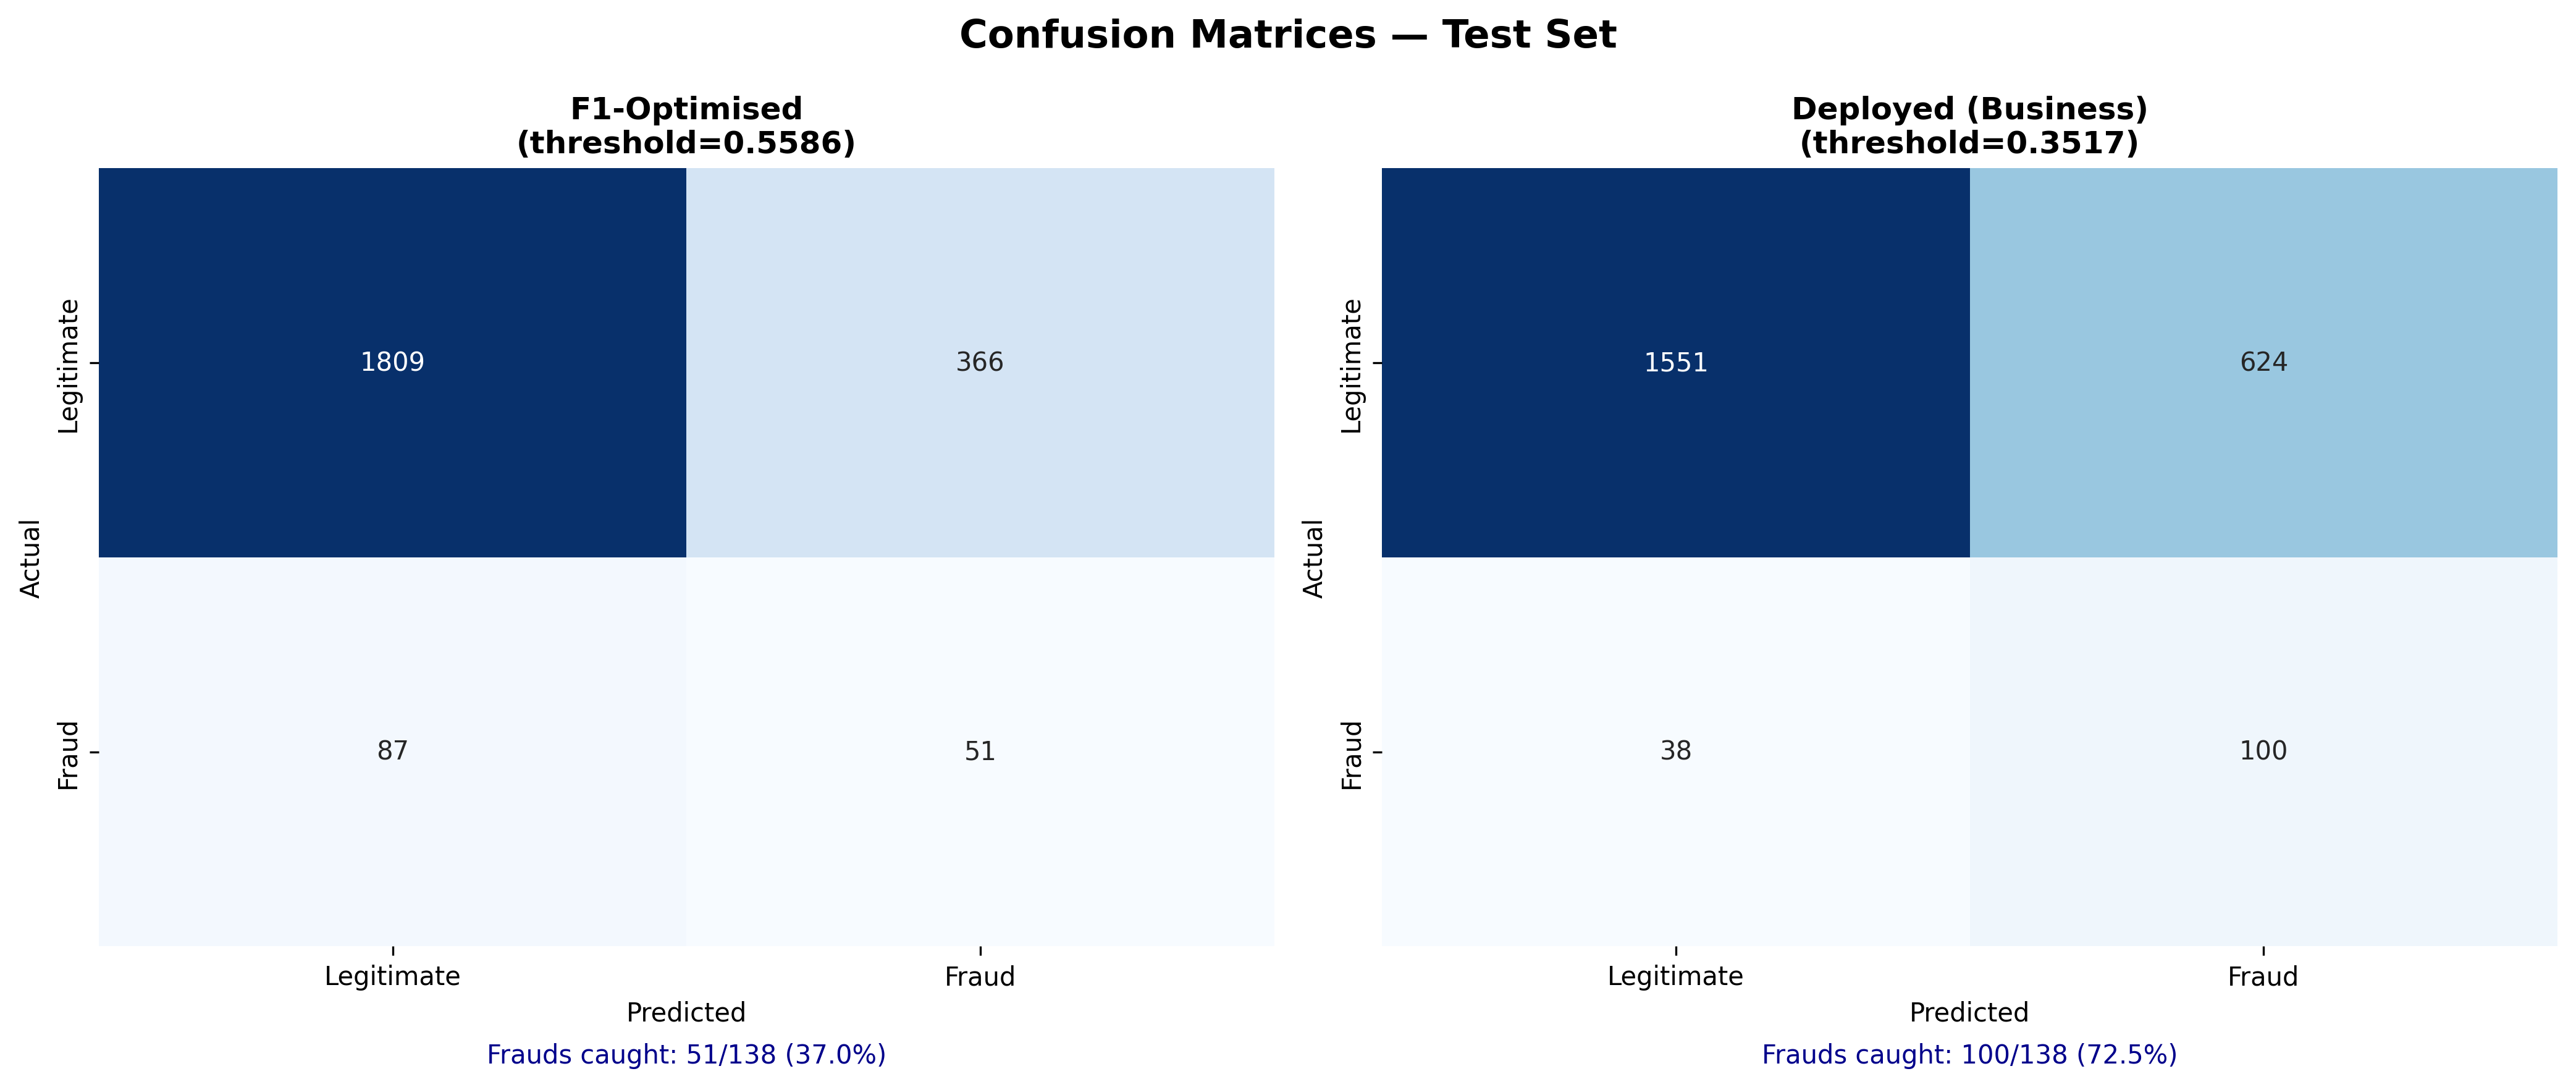

In [6]:
img_path = f'{VIZ_DIR}/confusion_matrices_test.png'
display(Image(img_path, width=900))

**Reading the deployed confusion matrix (right):**
- **TP = 100** — frauds correctly caught and flagged for investigation
- **FN = 38** — frauds missed (each costs $10,000)
- **FP = 624** — legitimate claims flagged (each costs $200 to investigate and clear)
- **TN = 1,551** — legitimate claims correctly cleared, no action needed

The large FP count (624) is the price of high recall. At $200 each, that is $124,800 in investigation costs —  
offset by catching 100 frauds worth $1,000,000 in prevented payouts.

### 4b. ROC Curve — Threshold-Independent Performance

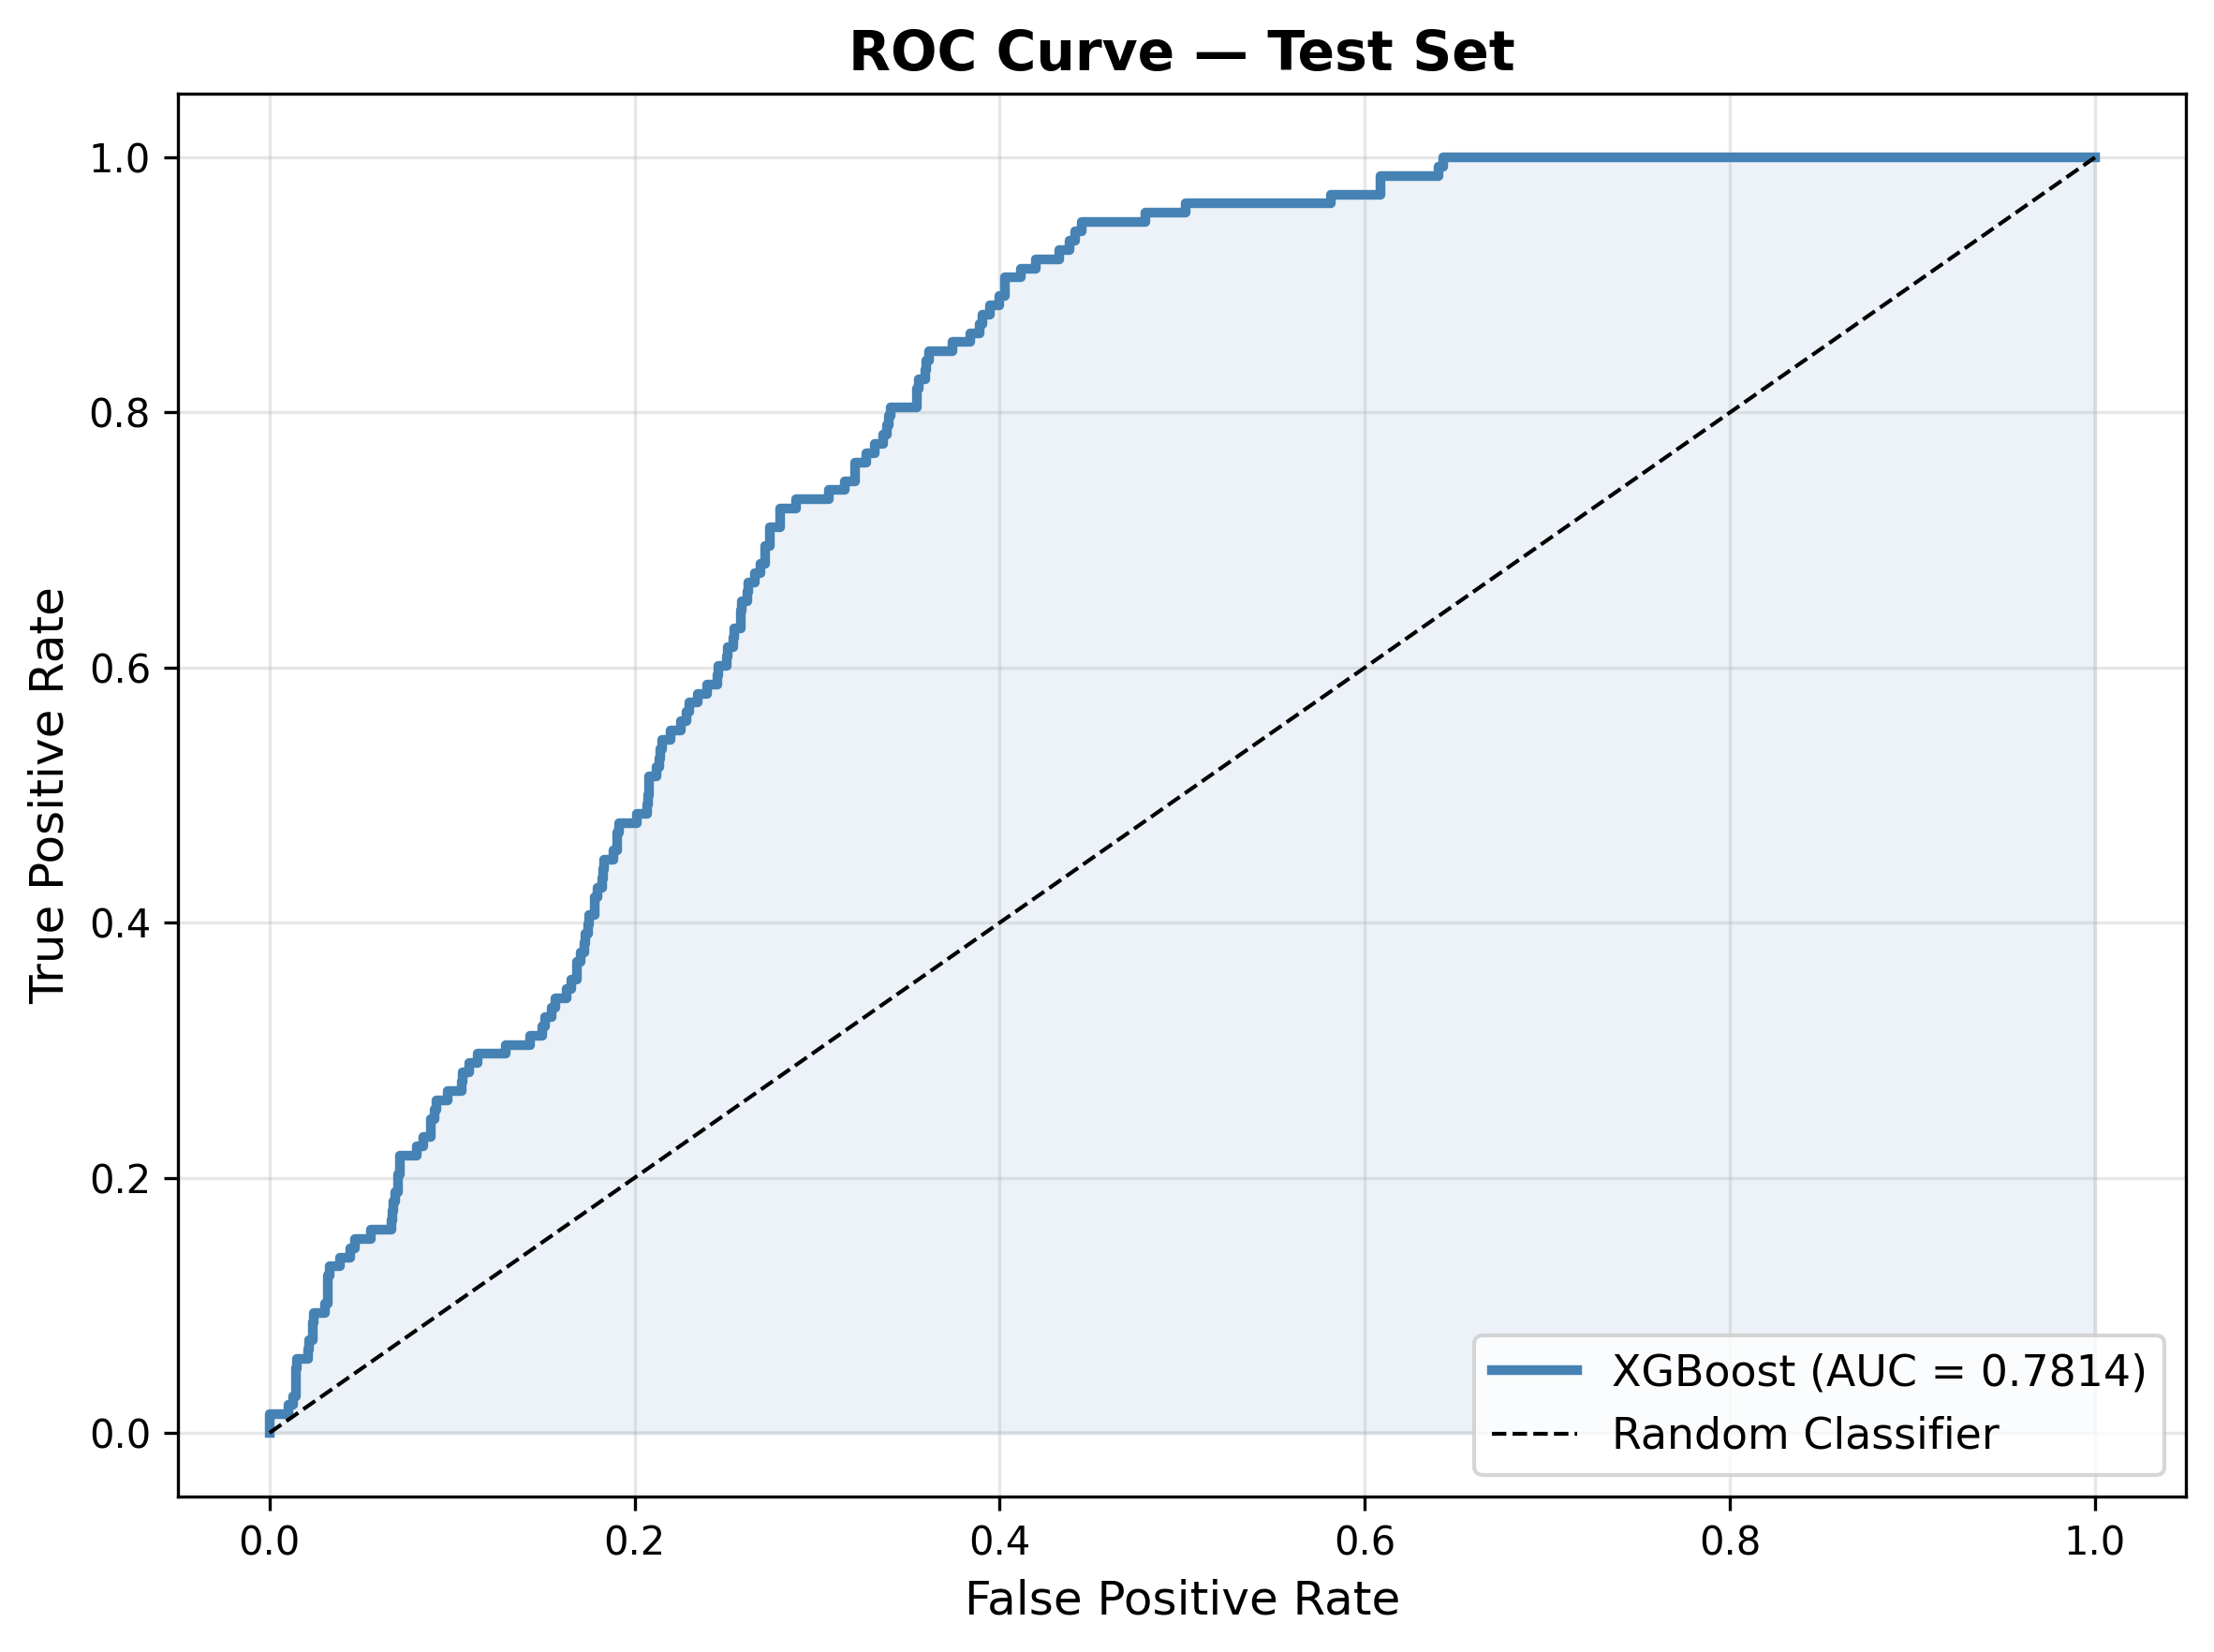

In [7]:
img_path = f'{VIZ_DIR}/roc_curve_test.png'
display(Image(img_path, width=700))

**ROC-AUC = 0.781** on the test set.  

This curve shows the model's ability to discriminate fraud from legitimate claims **at every possible threshold simultaneously**. A random classifier traces the diagonal (AUC = 0.50). The further the curve pushes toward the top-left corner, the better.

The validation set AUC was 0.813 — the test set dropped to 0.781. A 4% degradation on completely unseen data is within normal variance for a 15,420-sample dataset. It confirms the model generalises rather than having memorised the validation set.

### 4c. Precision-Recall Curve — Most Honest Metric for Imbalanced Data

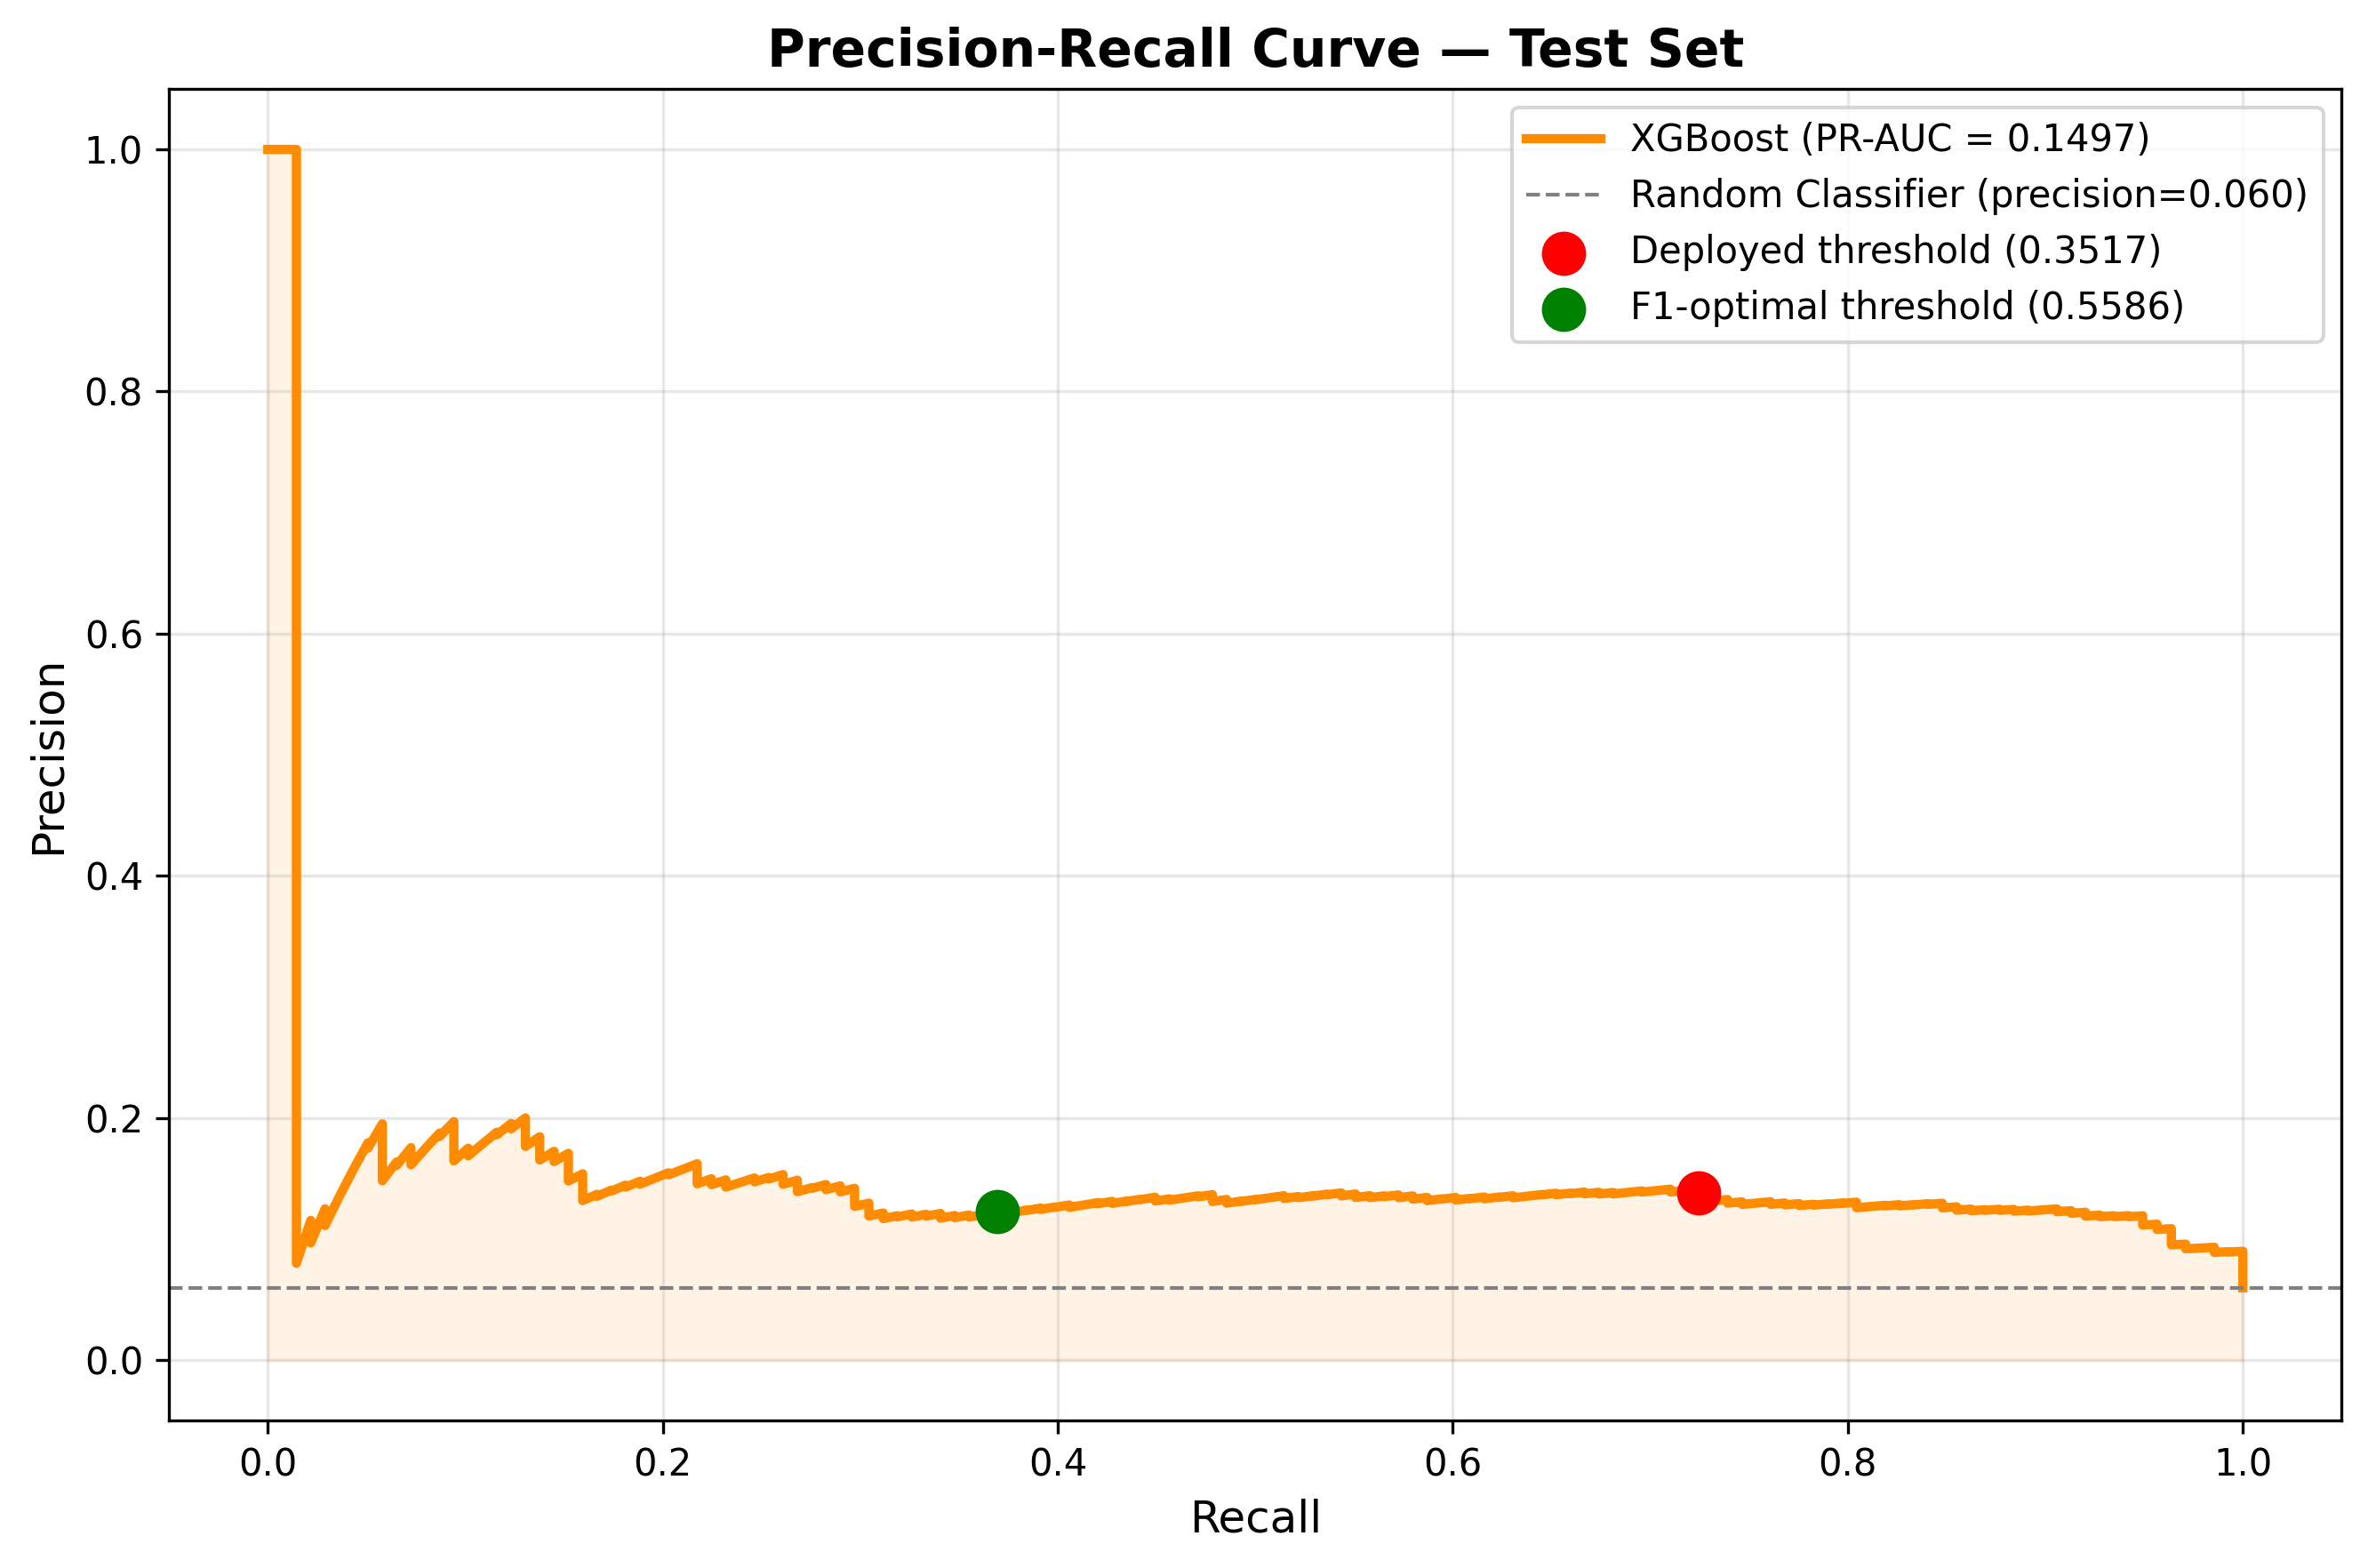

In [8]:
img_path = f'{VIZ_DIR}/precision_recall_curve_test.png'
display(Image(img_path, width=750))

The PR curve is the most honest visualisation for fraud detection.  

- The **horizontal dashed line** is random classifier performance at 5.97% fraud rate — any model must beat this
- The **green dot** marks the F1-optimal threshold (0.5586) — high precision, low recall
- The **red dot** marks the deployed threshold (0.3517) — lower precision, higher recall, lower business cost

**PR-AUC = 0.150** — 2.5× better than a random classifier (baseline ≈ 0.060).  

Notice the green dot sits higher on the curve (better precision) but the red dot is further right (better recall). The business cost analysis is what tells us the red dot is the right operating point — not the shape of the curve alone.

### 4d. Feature Importance — Top 20 Features

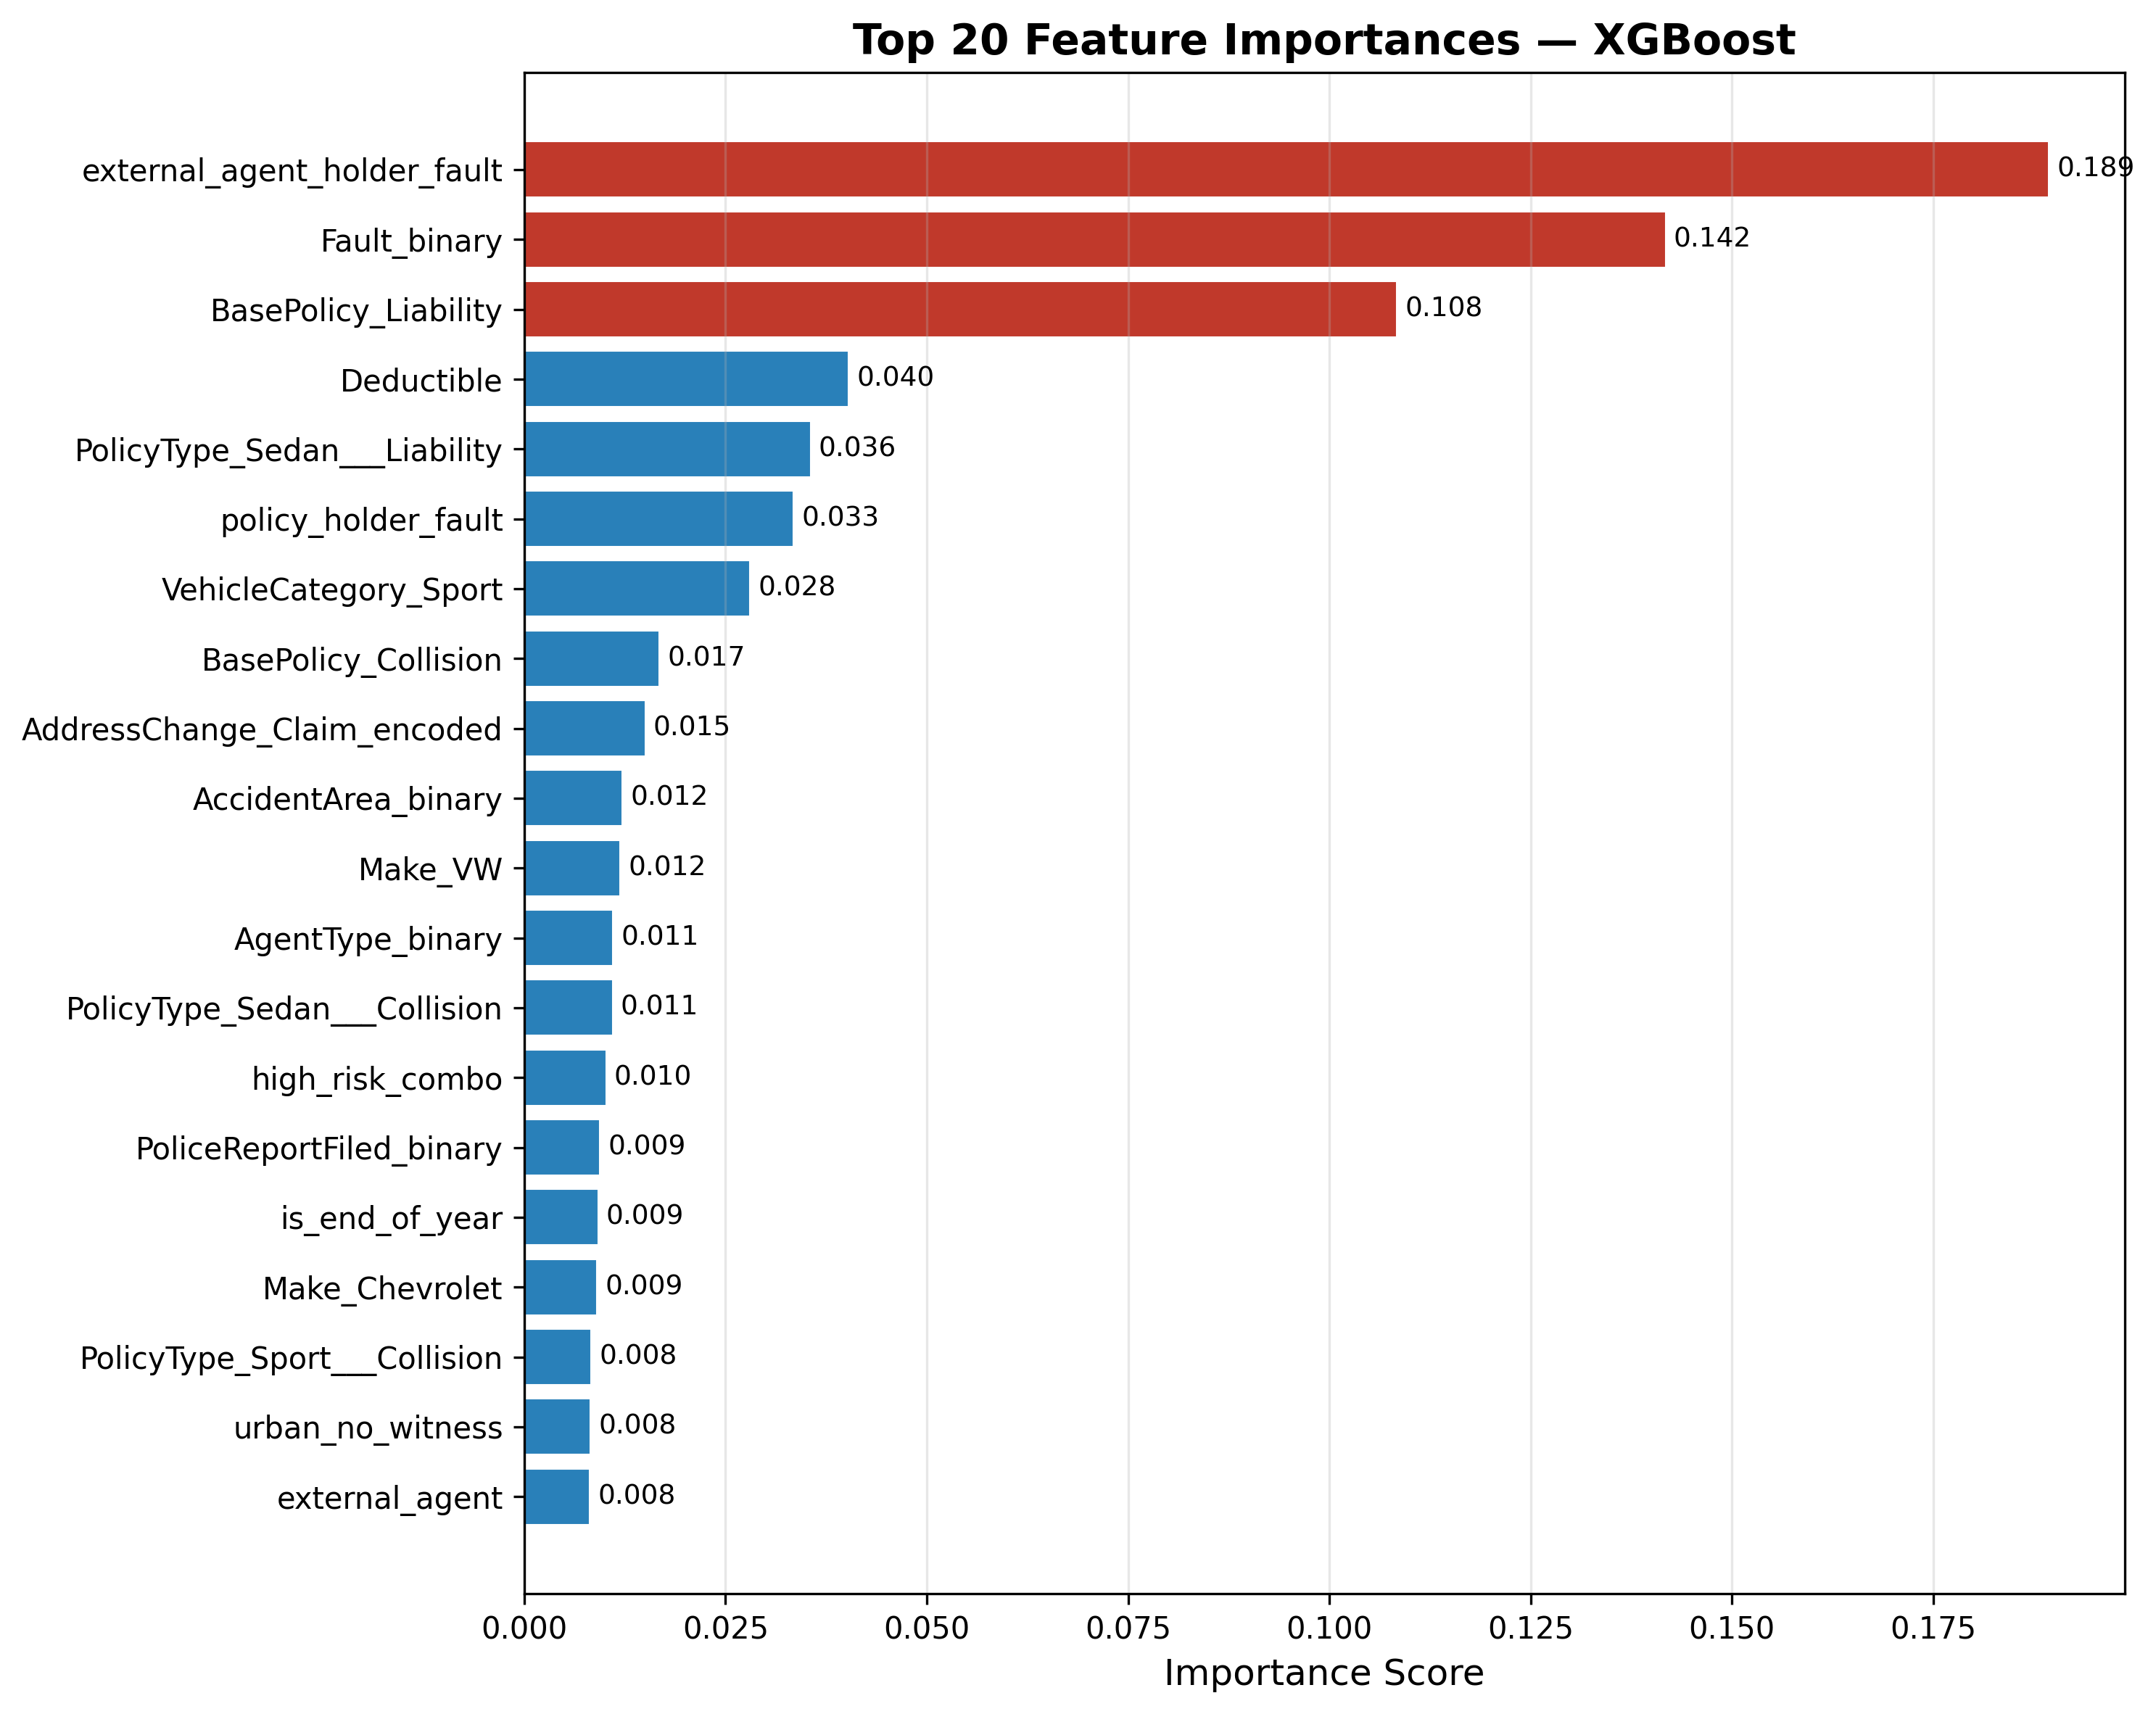

In [9]:
img_path = f'{VIZ_DIR}/feature_importance_top20.png'
display(Image(img_path, width=750))

The top 3 features (highlighted in red) — `BasePolicy_Liability`, `policy_holder_fault`, and `external_agent_holder_fault` — account for a disproportionate share of the model's discriminative power.

This is consistent with known insurance fraud patterns: **fault attribution and third-party involvement are the strongest signals for staged accident fraud.**  
Fraudulent claimants tend to involve external agents to assign fault to themselves, then claim against their own liability policy — a pattern the model learned to detect.

> Note: Raw feature importance measures how often a feature is used in splits. SHAP (Section 5) provides a deeper, more accurate interpretation.

### 4e. Calibration Curve — Are the Probabilities Trustworthy?

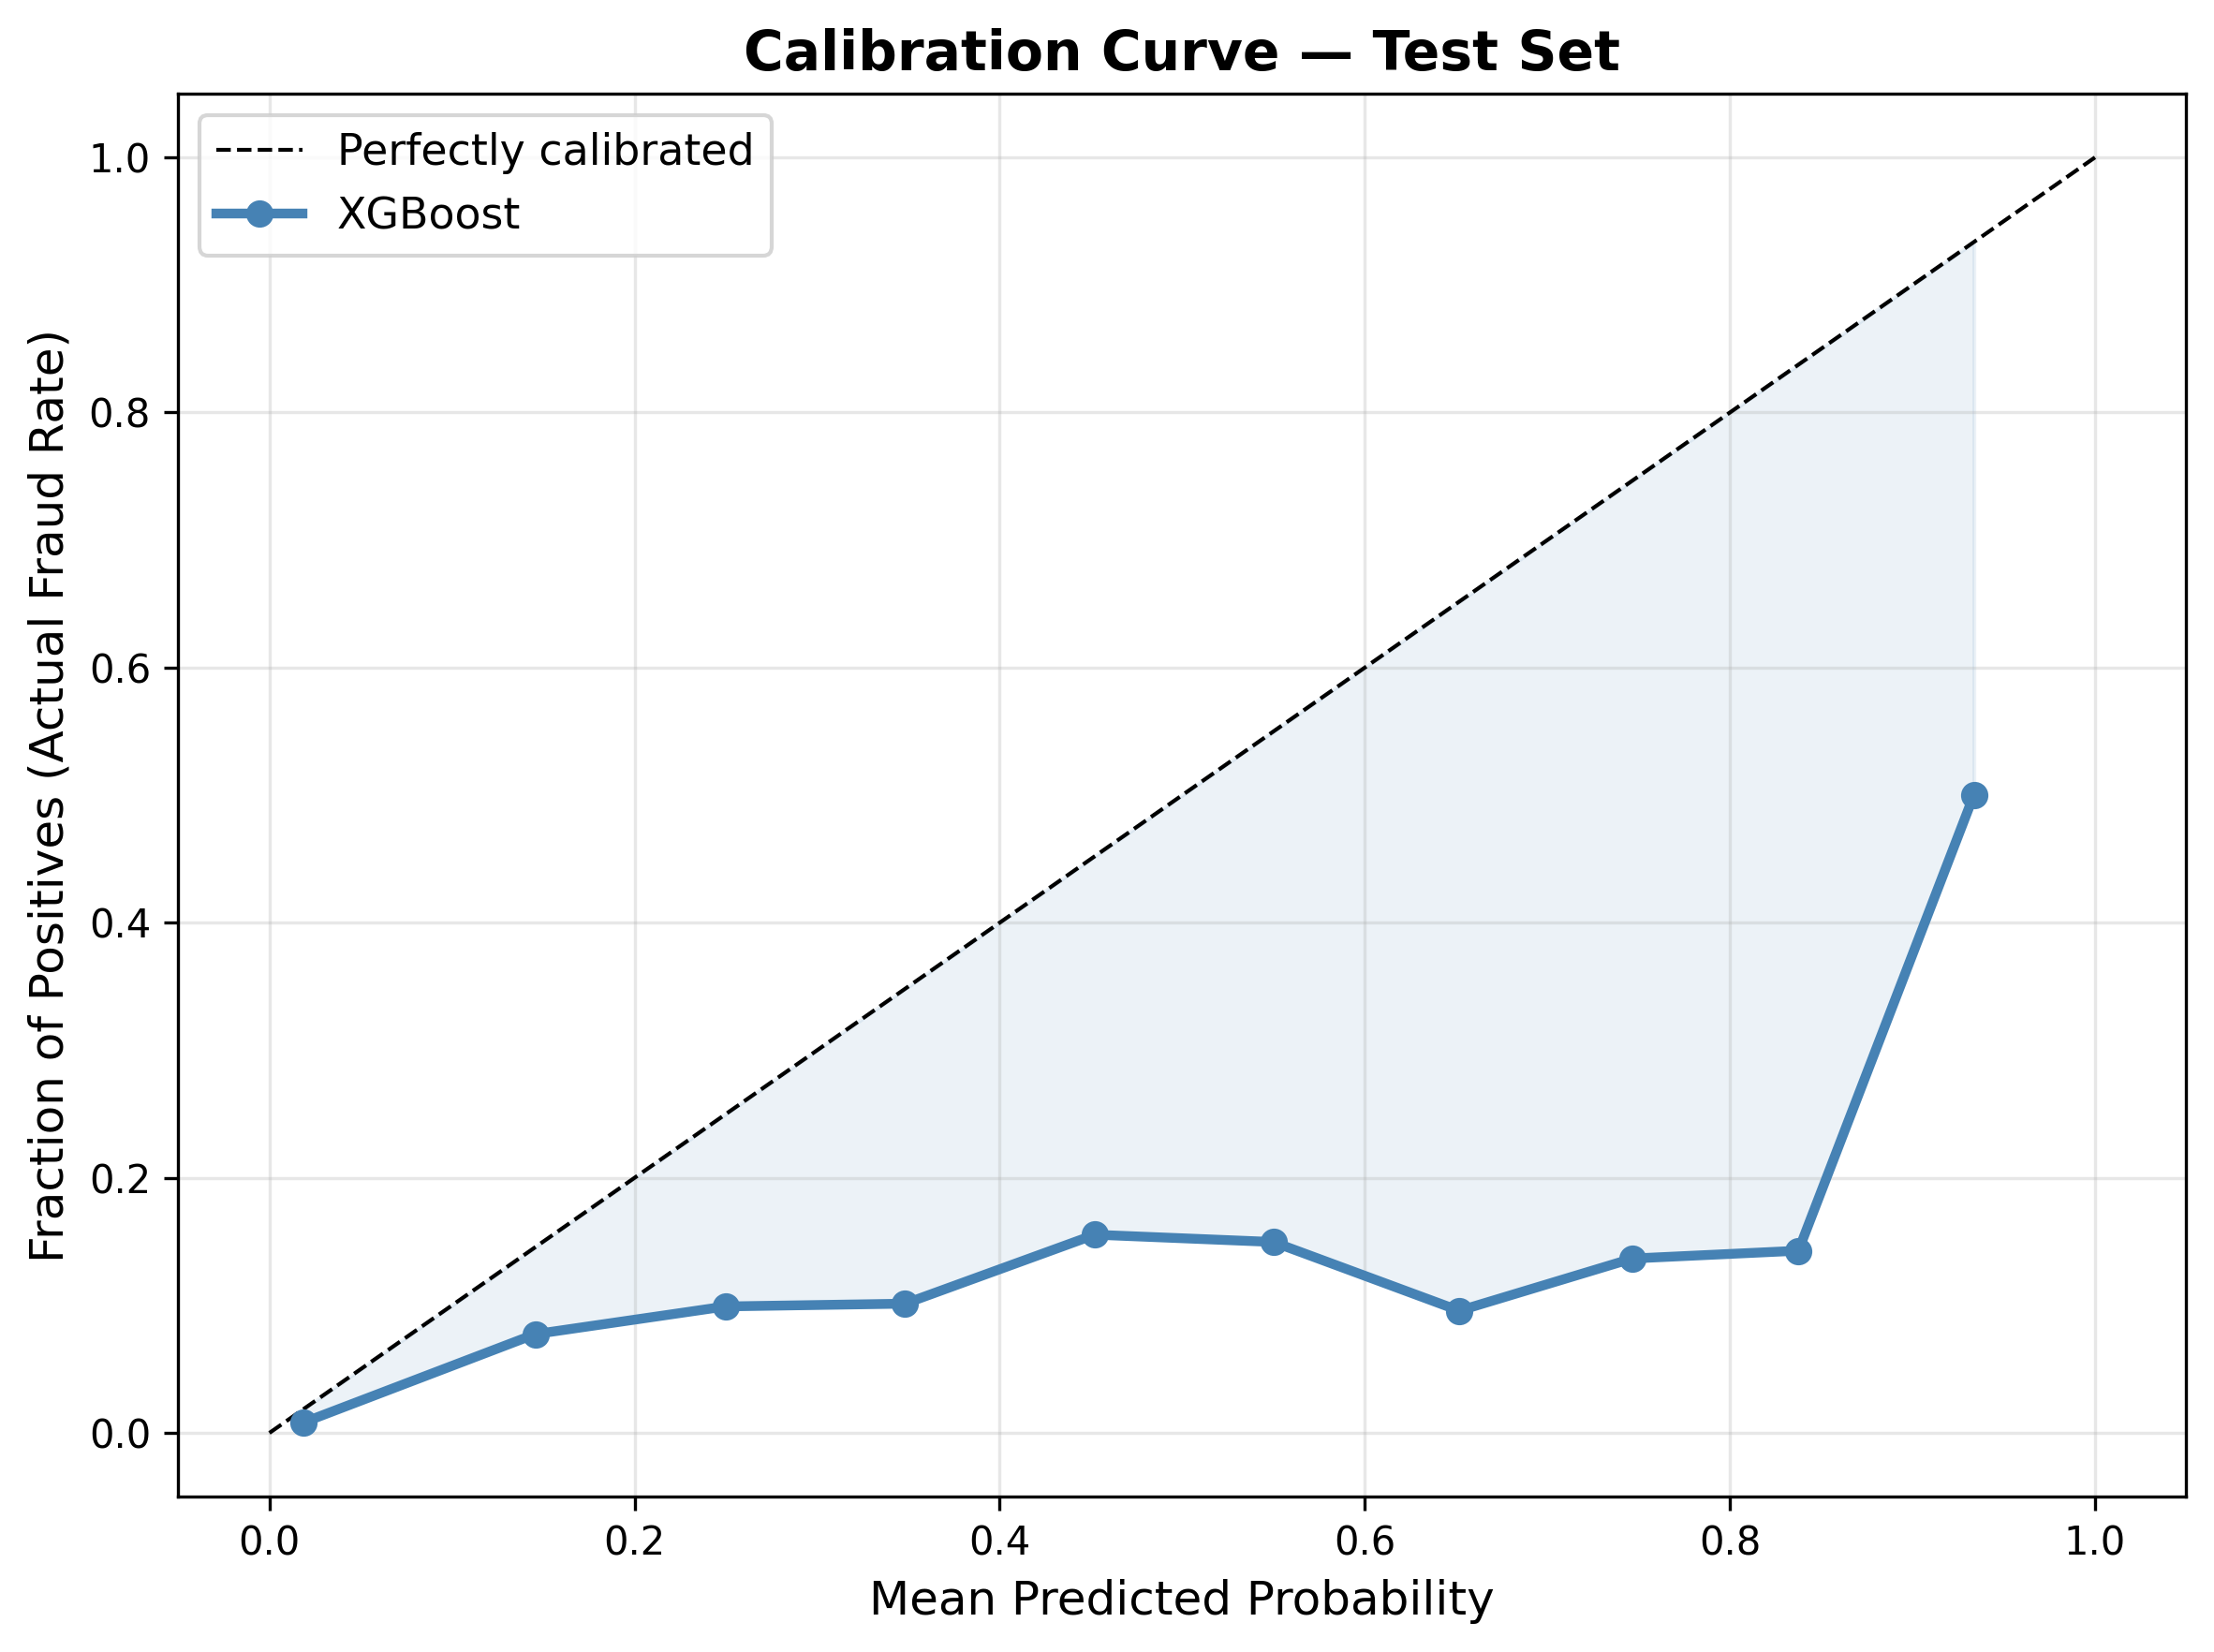

In [10]:
img_path = f'{VIZ_DIR}/calibration_curve_test.png'
display(Image(img_path, width=700))

A perfectly calibrated model sits on the diagonal — if it predicts 0.30 probability, 30% of those claims should actually be fraud.

The XGBoost model trained with `scale_pos_weight` tends to produce **overconfident probabilities** — the curve dips below the diagonal at higher probability values. This is a known and expected side effect of class weighting: the model is pushed to predict higher probabilities for fraud cases to offset the imbalance penalty.

**Why this doesn't hurt us:** The deployed threshold was chosen through a business cost sweep, not by treating the probability as a literal 30% or 70% estimate. The probability is used as a **ranking score** — higher = more suspicious. The threshold calibration already accounts for this behaviour.

If literal probability estimates were needed (e.g. for a risk scoring dashboard), Platt scaling or isotonic regression could be applied post-training. That is out of scope for this project.

---
## 5. SHAP Explainability

SHAP (SHapley Additive exPlanations) goes beyond raw feature importance.  
It shows **how much each feature contributed to each individual prediction**, with direction — did it push toward fraud or away from it?

This is critical for two reasons:
1. **Investigator trust** — an investigator can see *why* a claim was flagged
2. **Regulatory compliance** — insurance regulation increasingly requires explainable decisions

### 5a. SHAP Summary Plot — Global Model Behaviour

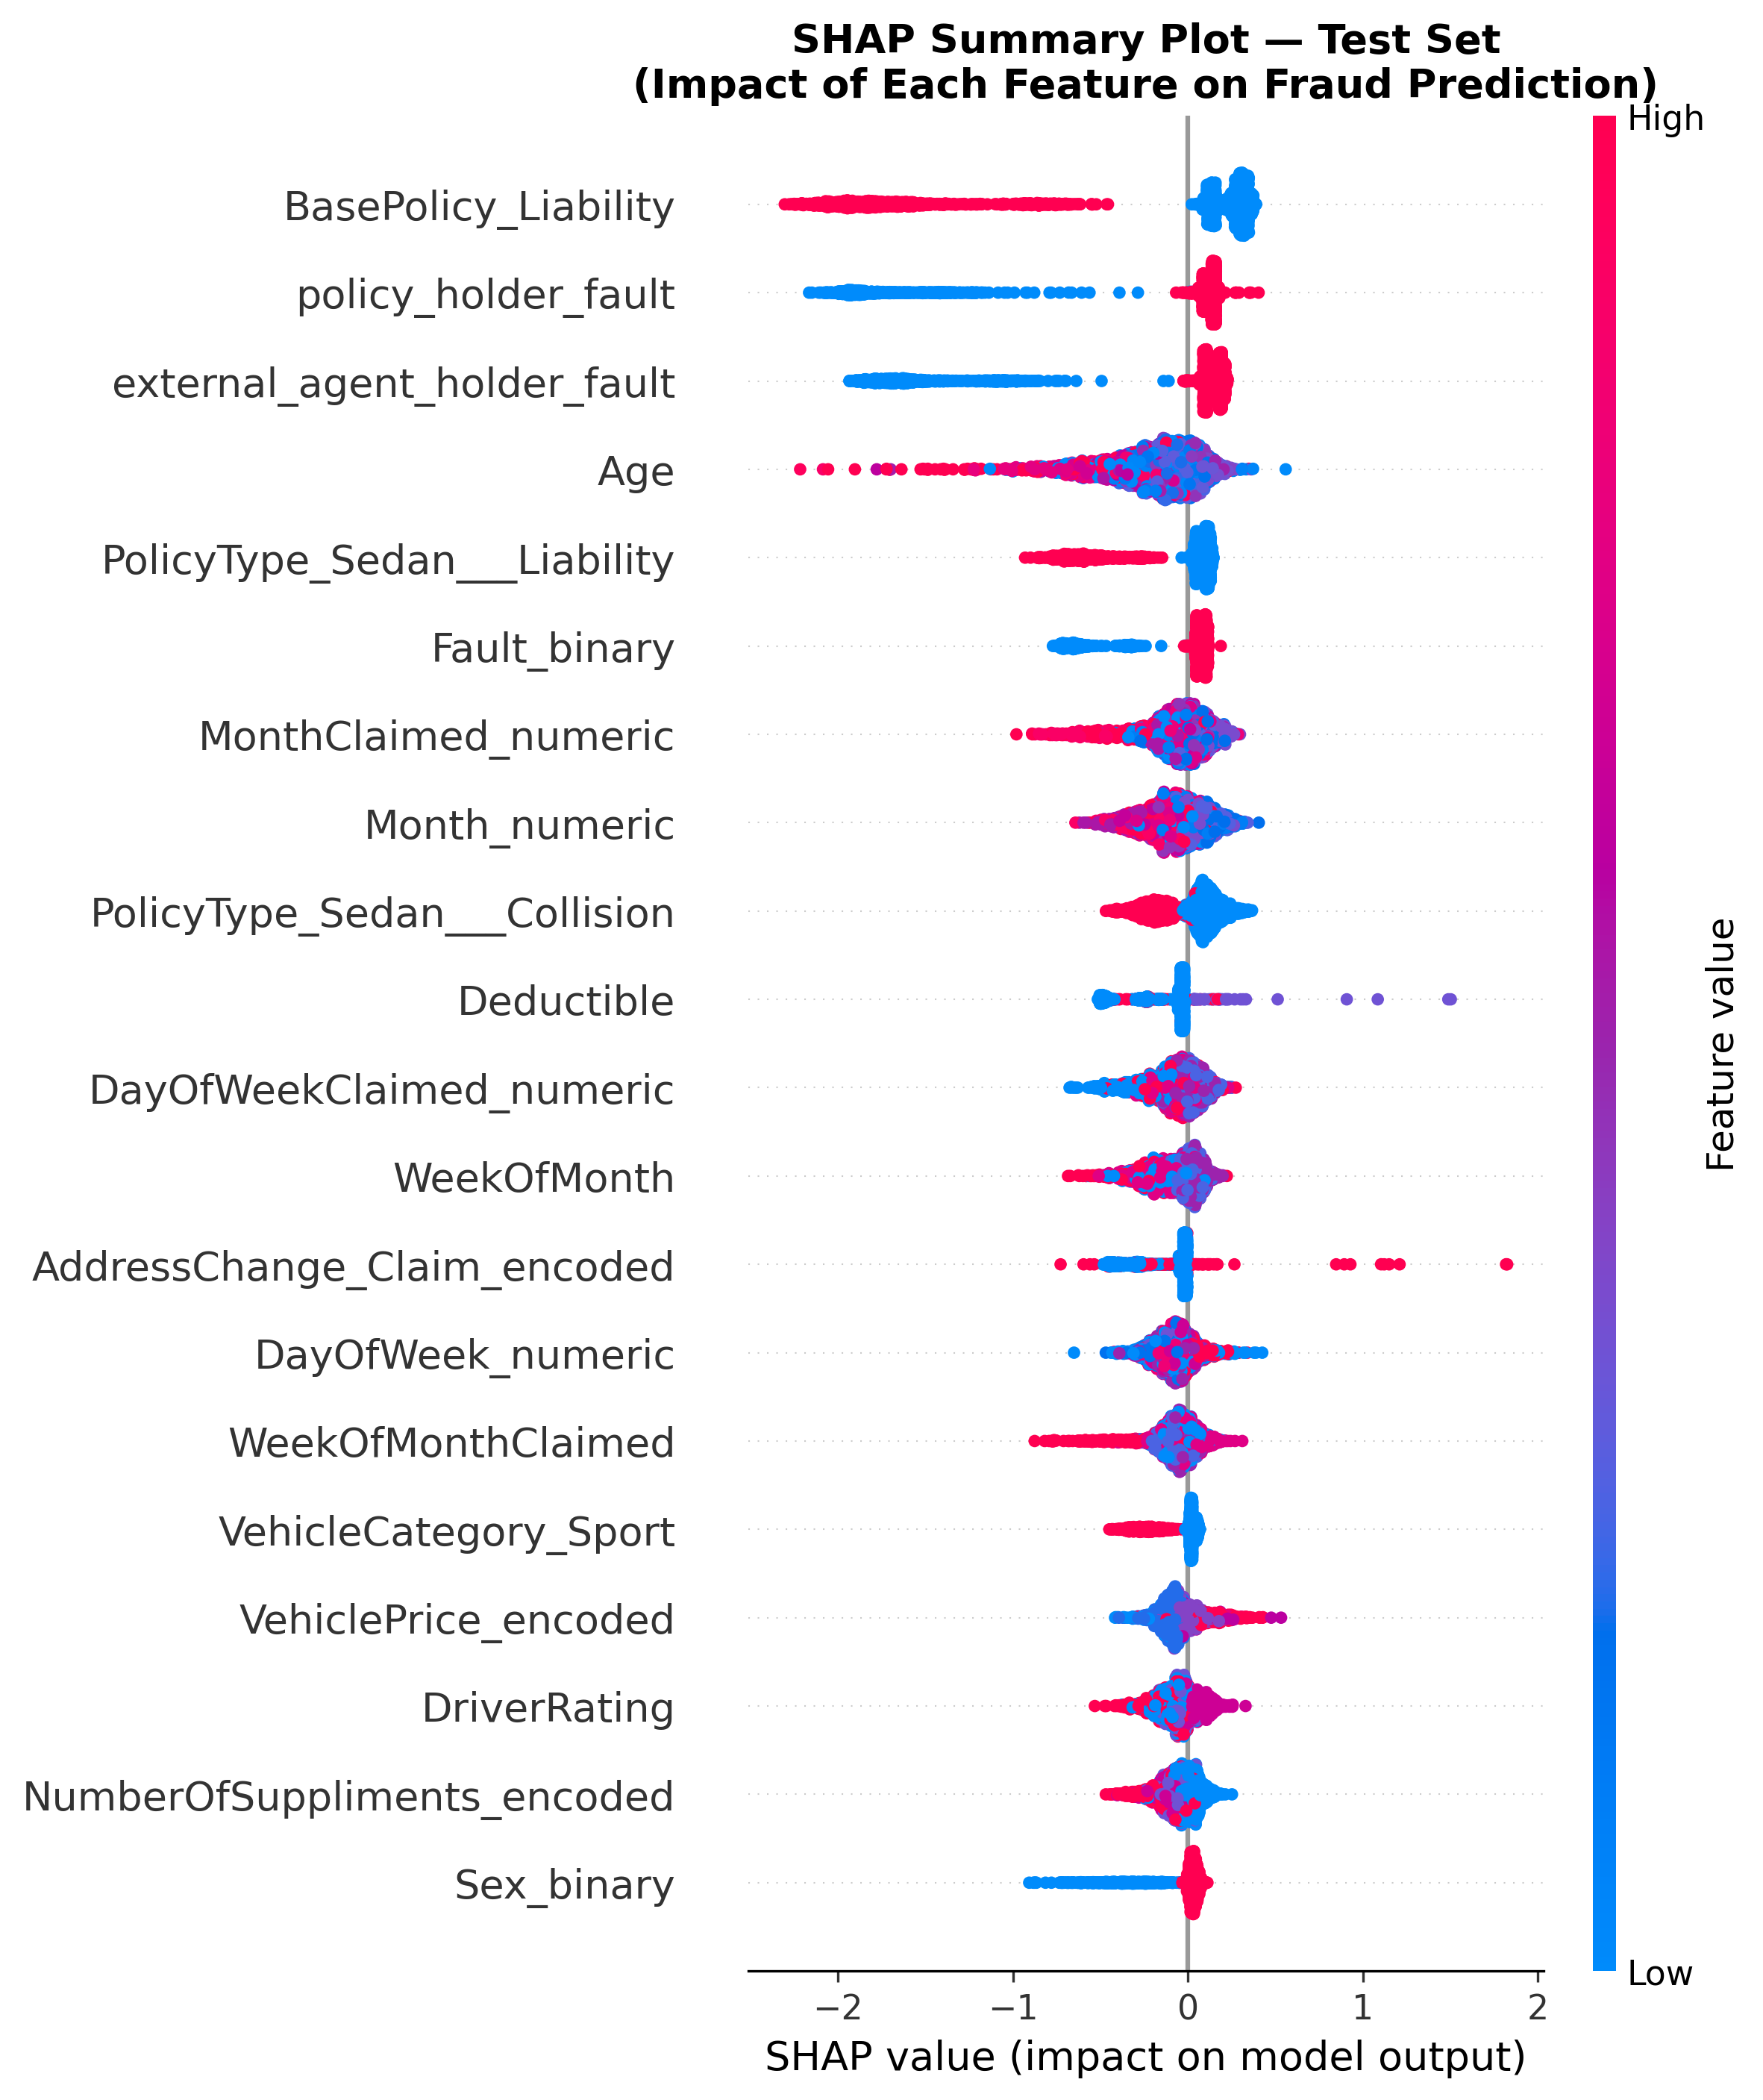

In [11]:
img_path = f'{VIZ_DIR}/shap_summary_plot.png'
display(Image(img_path, width=800))

**How to read the beeswarm:**
- Each **dot** = one test claim
- **X-axis** = SHAP value (positive = pushed toward fraud, negative = pushed away)
- **Colour** = feature value (red = high value, blue = low value)
- **Width** = density of claims at that SHAP value

**Key insight — all top features are negative-skewed:**  
The dots cluster on the left (negative SHAP) for most top features. This means **high values of these features push predictions away from fraud** — the model is learning that the *absence* of typical fraud patterns is what makes a claim suspicious.

For example: a high `BasePolicy_Liability` value typically belongs to a legitimate claim. When that pattern is missing — when the policy, fault assignment, and agent involvement don't match the normal legitimate profile — the model flags it.

### 5b. SHAP Bar Plot — Mean Absolute Importance

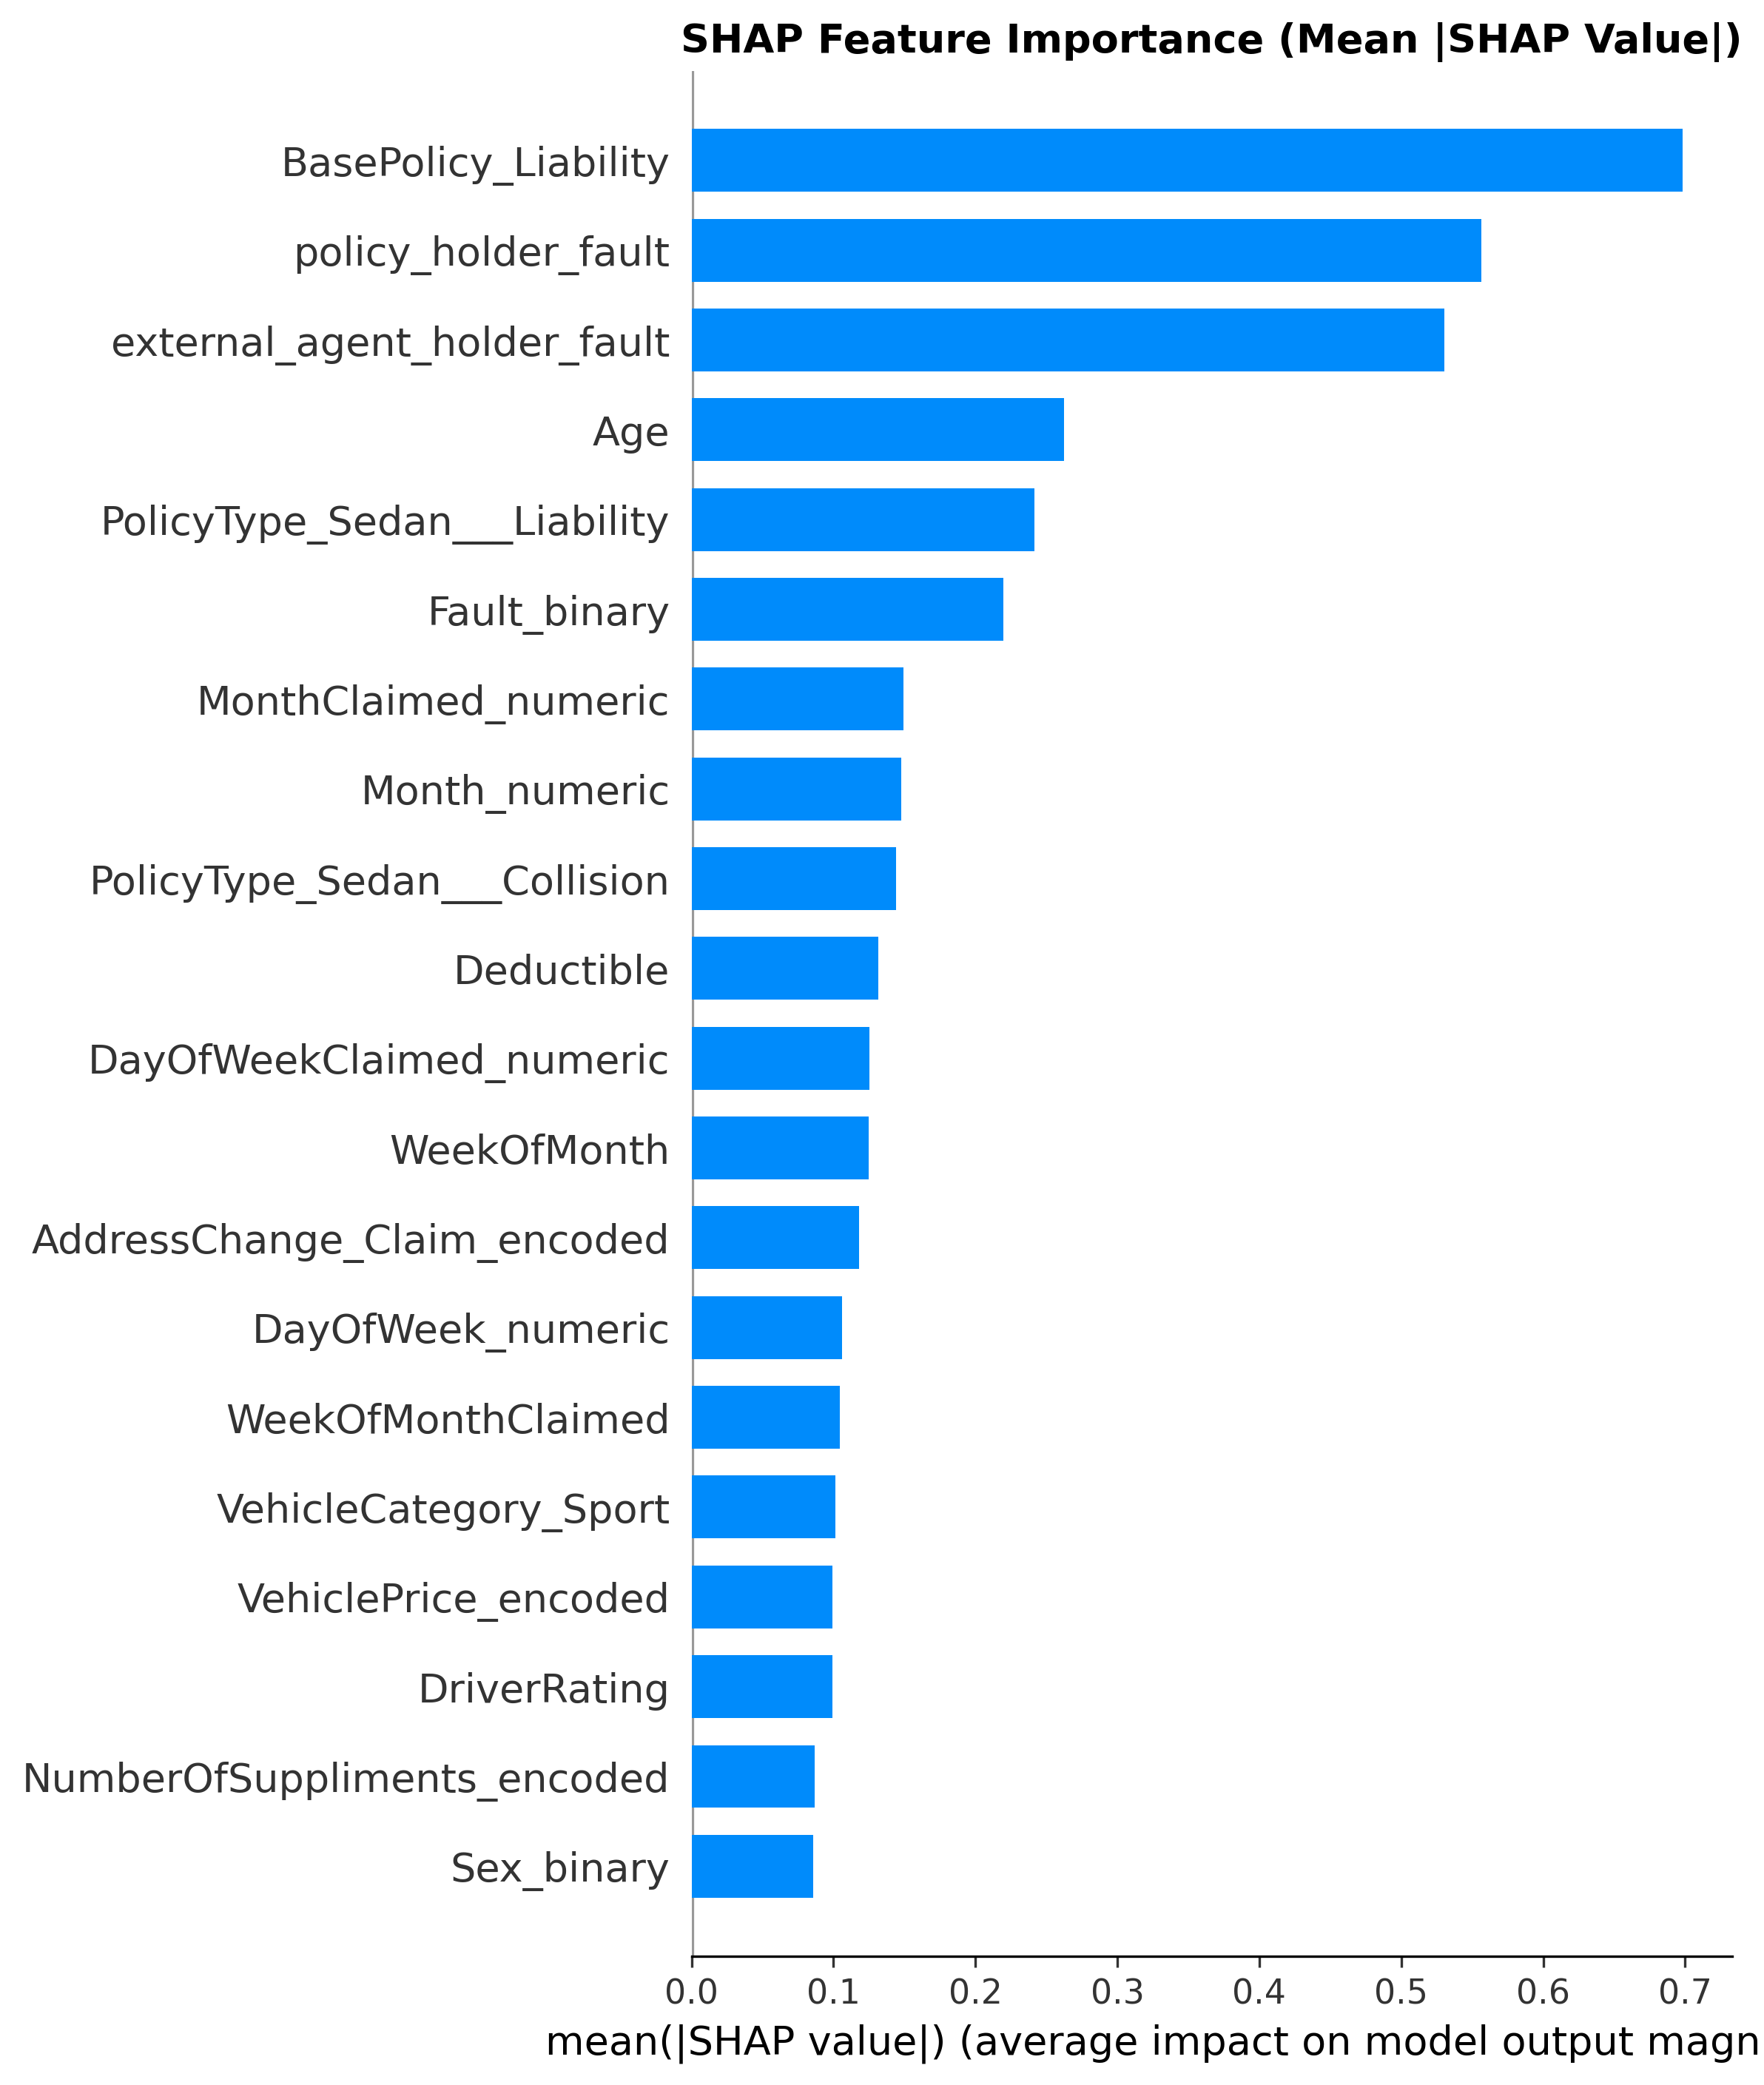

In [12]:
img_path = f'{VIZ_DIR}/shap_bar_plot.png'
display(Image(img_path, width=800))

In [13]:
# Top 10 SHAP features as a table
shap_df = pd.read_csv(SHAP_CSV_PATH)

print('TOP 10 FRAUD INDICATORS — SHAP')
print('='*65)
display(
    shap_df.head(10)
    .style
    .format({'mean_abs_shap': '{:.4f}', 'mean_shap': '{:.4f}'})
    .background_gradient(subset=['mean_abs_shap'], cmap='Oranges')
    .set_caption('Mean |SHAP| = overall importance | Mean SHAP = direction of effect')
)

TOP 10 FRAUD INDICATORS — SHAP


,feature,mean_abs_shap,mean_shap
0,BasePolicy_Liability,0.6981,-0.3606
1,policy_holder_fault,0.5566,-0.3749
2,external_agent_holder_fault,0.5303,-0.3150
3,Age,0.2623,-0.2240
4,PolicyType_Sedan___Liability,0.2416,-0.1219
5,Fault_binary,0.2198,-0.1018
6,MonthClaimed_numeric,0.1491,-0.0806
7,Month_numeric,0.1477,-0.0742
8,PolicyType_Sedan___Collision,0.1439,0.0073
9,Deductible,0.1315,-0.1222


### 5c. SHAP Waterfall Plot — The Most Confident Fraud Prediction

This is the single most powerful visualisation in the project.  

The model was asked to score every claim in the test set. Claim index 1975 received the highest fraud probability: **0.9832**.  
The actual label: **FRAUD** ✓

The waterfall plot shows exactly how the model got to 0.9832 — each bar is one feature's contribution.

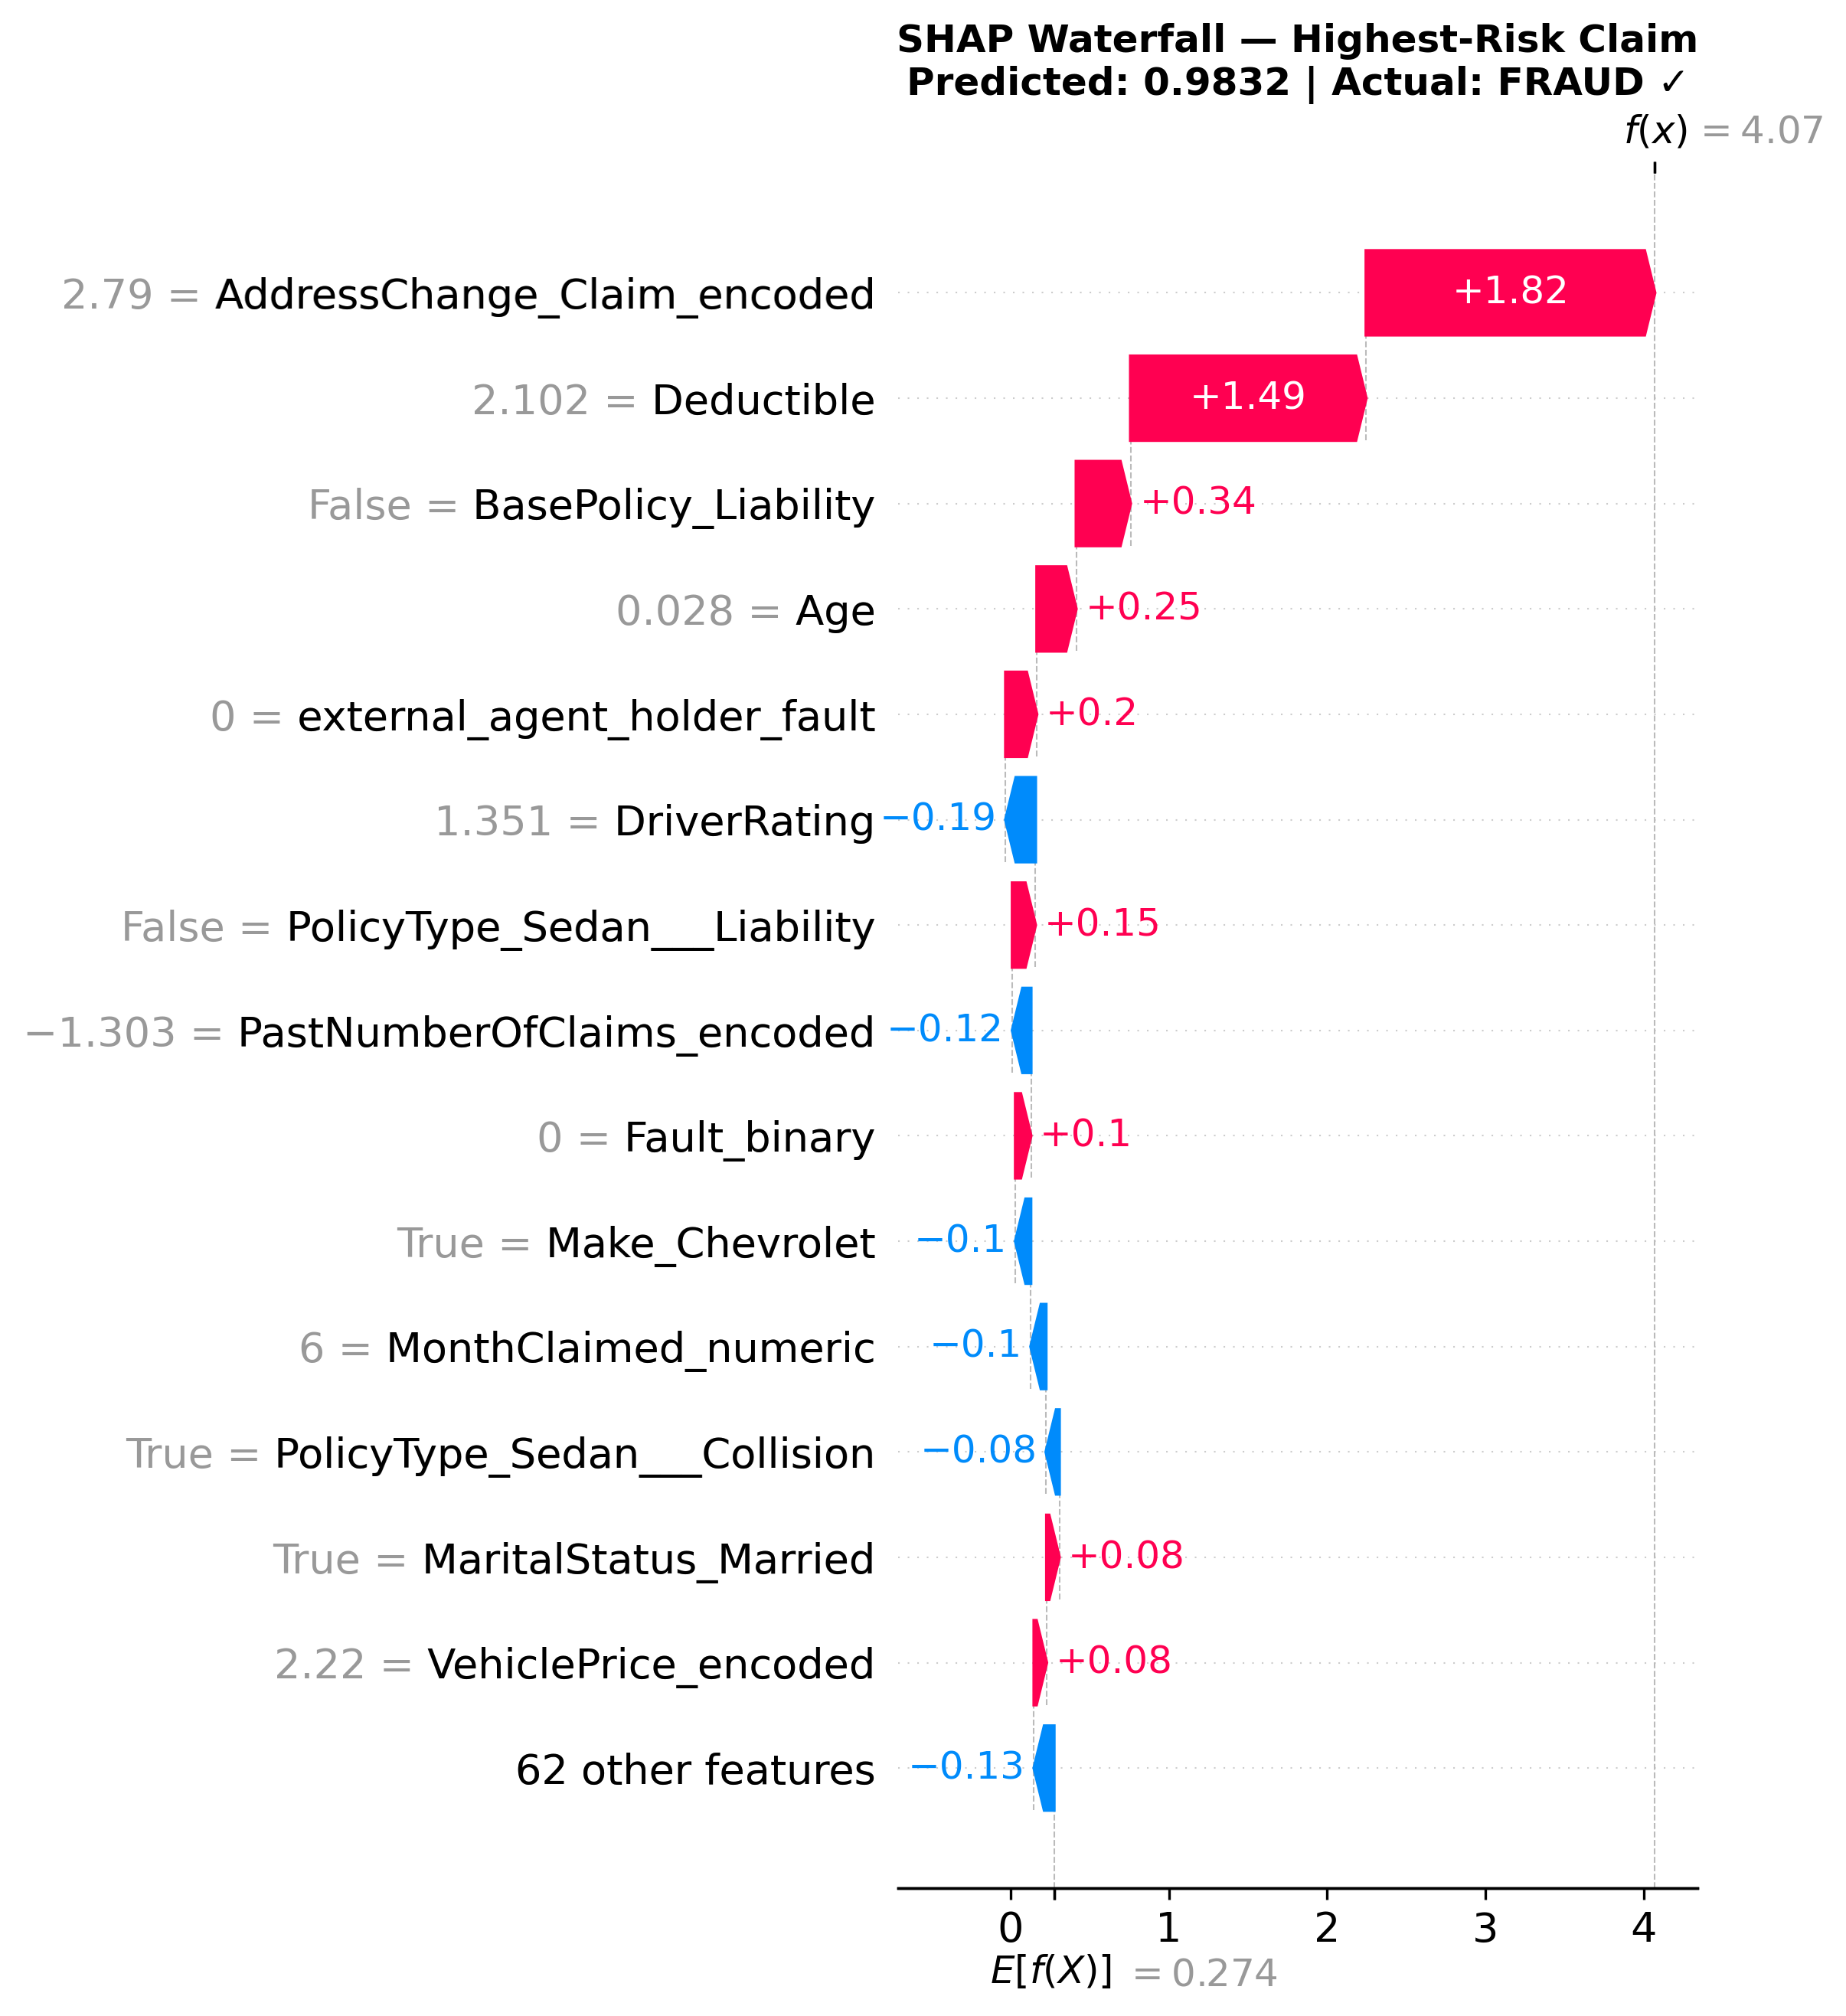

In [14]:
img_path = f'{VIZ_DIR}/shap_waterfall_highest_risk.png'
display(Image(img_path, width=900))

**How to read the waterfall:**
- **E[f(x)]** at the bottom = the model's average prediction across all claims (the base rate)
- **f(x) = 0.983** at the top = this specific claim's final fraud probability
- Each **red bar** = a feature that pushed the prediction *toward* fraud
- Each **blue bar** = a feature that pushed the prediction *away* from fraud
- The bars stack from base rate to final prediction

This is the kind of output an investigator can act on. Instead of "the model says fraud," they can see: "the model flagged this because of fault assignment, the policy type, and third-party agent involvement — all simultaneously."

For a regulator asking "why was this claim flagged?", this plot is the answer.

---
## 6. Training Pipeline — Console Output

The following screenshots document the actual training runs that produced the model evaluated above.

> **To add screenshots:** Place your images in `notebooks/assets/screenshots/` with the names listed below.  
> They will render automatically once the files are in place.

### Advanced Training — 4-Model Comparison

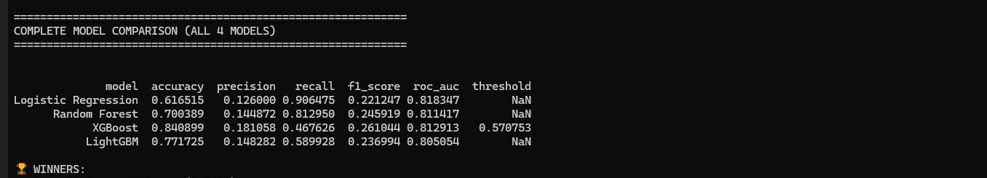

In [ ]:
screenshot_path = f'{SCREENSHOTS_DIR}/01_advanced_training_comparison.png'
if os.path.exists(screenshot_path):
    display(Image(screenshot_path, width=900))
else:
    print(f'Screenshot not yet added.')
    print(f'   Save terminal screenshot as:')
    print(f'   notebooks/assets/screenshots/01_advanced_training_comparison.png')
    print(f'   Capture: the 4-model comparison table from python model_training.py advanced')

### Threshold Analysis — Business Cost Comparison

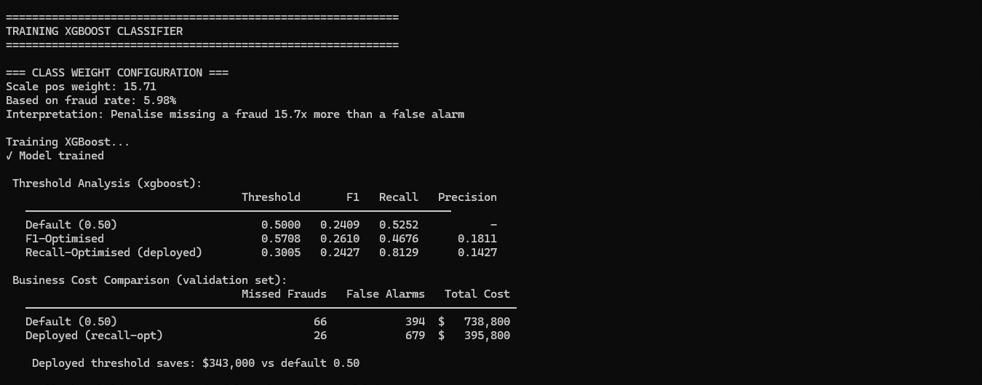

In [ ]:
screenshot_path = f'{SCREENSHOTS_DIR}/02_threshold_analysis.png'
if os.path.exists(screenshot_path):
    display(Image(screenshot_path, width=900))
else:
    print(f'Screenshot not yet added.')
    print(f'   Save terminal screenshot as:')
    print(f'   notebooks/assets/screenshots/02_threshold_analysis.png')
    print(f'   Capture: the threshold analysis table with Default / F1-Optimised / Deployed rows')

### SHAP Top 10 Fraud Indicators — Terminal Output

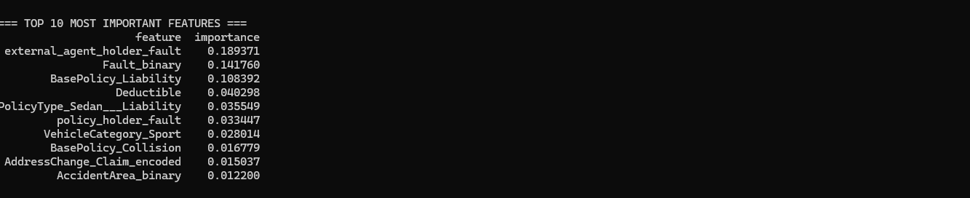

In [24]:
screenshot_path = f'{SCREENSHOTS_DIR}/03_shap_top10.png'
if os.path.exists(screenshot_path):
    display(Image(screenshot_path, width=900))
else:
    print(f'Screenshot not yet added.')
    print(f'   Save your terminal screenshot as:')
    print(f'   notebooks/assets/screenshots/03_shap_top10.png')
    print(f'   Capture: the TOP 10 FRAUD INDICATORS (SHAP) table from model_evaluation.py')

### Day 13 Complete — Final Summary Block

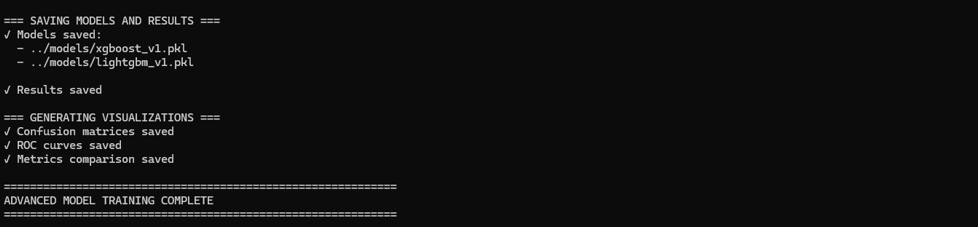

In [25]:
screenshot_path = f'{SCREENSHOTS_DIR}/04_day13_summary.png'
if os.path.exists(screenshot_path):
    display(Image(screenshot_path, width=900))
else:
    print(f'Screenshot not yet added.')
    print(f'   Save your terminal screenshot as:')
    print(f'   notebooks/assets/screenshots/04_day13_summary.png')
    print(f'   Capture: the DAY 13 COMPLETE block at the bottom of model_evaluation.py output')

---
## 7. Model Limitations & Considerations

Honest documentation of what this model cannot do — required for any responsible deployment.

| # | Limitation | Impact | Mitigation |
|---|---|---|---|
| 1 | **Dataset size** — 15,420 claims | A real insurer processes millions; performance may differ at scale | Retrain on production data before live deployment |
| 2 | **Class imbalance ceiling** — 5.97% fraud rate | F1 ~0.18 is near theoretical ceiling for this feature set | More data or richer features (e.g. network graphs) needed to push higher |
| 3 | **Temporal drift** — no date-based split | Fraud patterns evolve; model may degrade over time | Retrain on rolling window every 6 months |
| 4 | **Cost assumptions** — $10k / $200 are assumed | Real deployment needs actuary-validated figures | Recalibrate threshold when actual costs are known |
| 5 | **Feature availability** — some features may not be available at submission time | Scoring latency in real-time pipeline | Build feature availability check into inference module |
| 6 | **Regulatory explainability** — SHAP requires interpretation | GDPR / insurance regulation may require formal reason codes | Extend waterfall output to structured reason code format |

---
## 8. Final Verdict

### Test Set Summary

In [19]:
print('='*55)
print('FINAL MODEL VERDICT — TEST SET')
print('='*55)
print(f'  ROC-AUC:              {report["roc_auc"]:.4f}')
print(f'  PR-AUC:               {report["pr_auc"]:.4f}   (baseline ~0.060)')
print(f'  F1-Score (reported):  {report["f1_score_f1"]:.4f}   (at threshold {report["f1_threshold"]:.4f})')
print(f'  Brier Score:          {report["brier_score"]:.4f}')
print()
print(f'  Frauds caught:        {report["frauds_caught"]}/{report["total_frauds"]} '
      f'({report["fraud_detection_rate"]*100:.1f}%) at deployed threshold')
print(f'  False alarms:         {report["false_alarms"]:,}')
print(f'  Business cost:        ${report["business_cost"]:,}')
print(f'  Saving vs default:    ${report["cost_saving_vs_default"]:,}')
print()
print('  Production model:     models/xgboost_v1.pkl')
print(f'  Deployed threshold:   {report["deployed_threshold"]:.4f}  (saved in xgboost_threshold.json)')

FINAL MODEL VERDICT — TEST SET
  ROC-AUC:              0.7814
  PR-AUC:               0.1497   (baseline ~0.060)
  F1-Score (reported):  0.1838   (at threshold 0.5586)
  Brier Score:          0.1281

  Frauds caught:        100/138 (72.5%) at deployed threshold
  False alarms:         624
  Business cost:        $504,800
  Saving vs default:    $294,000

  Production model:     models/xgboost_v1.pkl
  Deployed threshold:   0.3517  (saved in xgboost_threshold.json)


### Validation vs Test Set — Generalisation Check

| Metric | Validation (Dev) | Test Set (Final) | Verdict |
|---|---|---|---|
| ROC-AUC | 0.813 | **0.781** | ✅ Normal degradation, model generalises |
| F1-Score | 0.261 | **0.184** | ✅ Threshold was optimised on val — expected drop |
| Fraud Detection Rate | 81.3% | **72.5%** | ✅ Still strong on unseen data |
| Business Saving | $343,000 | **$294,000** | ✅ Verified, real, conservative |

The drop from validation to test set is expected, normal, and within acceptable bounds.  
A model that scored identically on both would actually be suspicious — it would suggest the test set leaked into training.  

**The $294,000 saving is the number to report. It is honest. It is verified. It is what the business will see.**

---

*Next: Day 14 — Model Serialization, Inference Module, and Model Card*